# Online Forum Multi-Label Communicative Type Classification

Casual online forum comments written in **Bahasa Melayu**, **English**, and **Manglish** from Lowyat Kopitiam are classified according to the communicative purpose expressed by the user.

### The 6 Communicative Categories
- **Inquiry**: Questions, seeking help, recommendations, or troubleshooting.
- **Complaint**: Venting frustration, complaining about bad service, high prices, or problems.
- **Opinion**: Personal viewpoints, beliefs, reviews, or arguments.
- **Information**: Objective facts, news, official updates, guides, or links.
- **Expressive**: Jokes, laughing, memes, greetings, or casual banter.
- **Spam**: Unwanted promotional links, referral links, or automated bot posts.

A single forum comment may serve multiple communicative purposes; therefore, **Multi-Label Classification** is used.

# 0.0 Environment Setup & Configuration
The required dependencies are installed and non-critical library warnings are suppressed for clean execution.

## 0.1 Install Required Libraries
The project dependencies are specified in `requirements.txt`.

In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## 0.2 Suppress Warnings & Markdown Helper Setup
Configure warning filters, set Pandas column width display options, and define `printmd()`.

In [2]:
import warnings
import pandas as pd
from IPython.display import display, Markdown, HTML

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Disable text truncation in DataFrame displays
pd.set_option('display.max_colwidth', None)
def printmd(string):
    display(Markdown(string))

# Step 1: Load Dataset & Exploratory Data Analysis (EDA)
The annotated forum dataset is loaded to inspect total records, target intent distributions, average word count per communicative category, and multi-label intent combination co-occurrences.

### 1.1 Load Dataset & Preview Records
The raw CSV dataset is loaded into Pandas to inspect record count, schema, and sample forum comments.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv("dataset.csv", encoding="utf-8")

# Target intent columns
target_cols = ['Inquiry', 'Complaint', 'Opinion', 'Information', 'Expressive', 'Spam']

# Display basic summary and preview of records
printmd(f"**Dataset Summary:** `{len(df):,}` total rows, `{df.shape[1]}` columns")
printmd("#### Preview of First 5 Records:")
display(df.head())

**Dataset Summary:** `99,104` total rows, `8` columns

#### Preview of First 5 Records:

,id,text,Inquiry,Complaint,Opinion,Information,Expressive,Spam
0,1,the feast starts now!,0,0,0,0,1,0
1,2,Shake shake 5pm\n\nhttps://games.shopee.com.my/universal-link/...95515050372?f=1,0,0,0,1,0,1
2,3,Situasi dlm keta\n\nKau : padu betul\n\nDia : padu apa??\n\nKau : eh bkn..pandu betul betul,0,0,0,0,1,0
3,4,currently he is playing for india?\nwooooh.....tat's new,1,0,0,0,1,0
4,5,"QUOTE(ahmad92 @ Dec 17 2022, 01:03 PM)Oi apek, i bunuh empat orang with low health in overpass you tak post. Hahaha\nManada. Tatau tatau 🤣🤣🤣🤣🤣🤣",0,0,0,0,1,0


### 1.2 Individual Intent Distribution & Average Post Length (Word Count)
Visualizes the overall distribution of the 6 communicative intent classes alongside the average post length (word count) for each intent category.

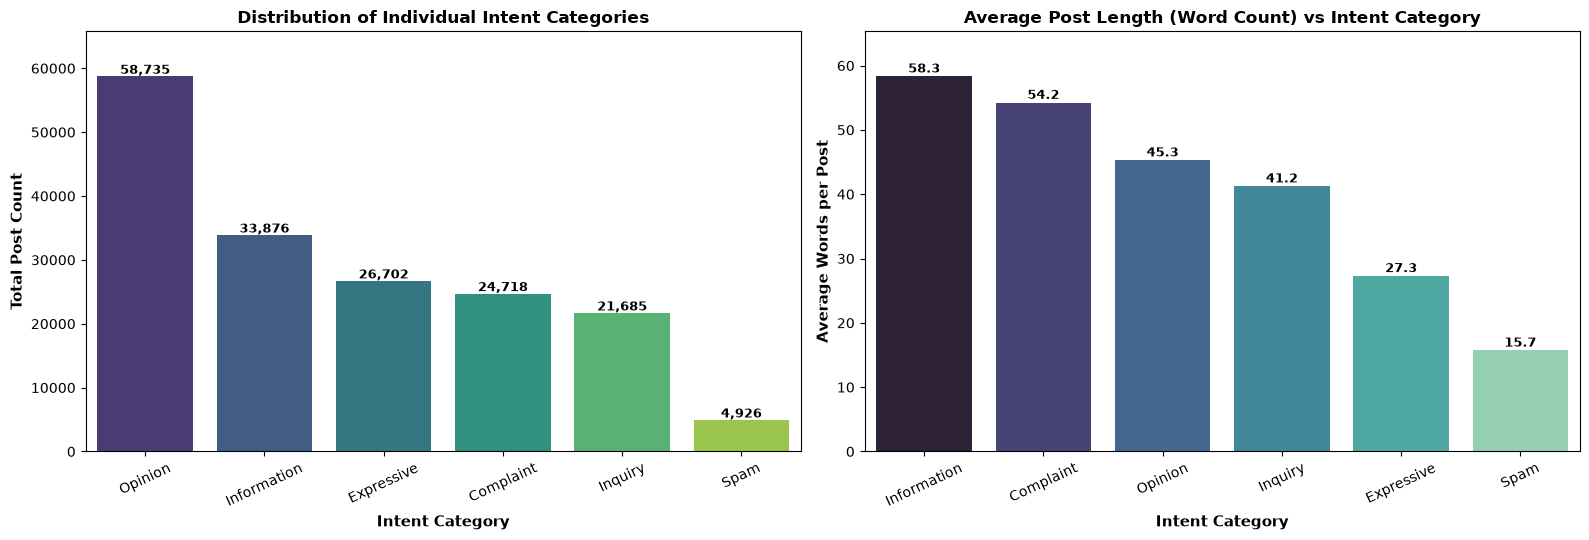

In [4]:
# 1. Compute Individual Target Intent Distribution
intent_counts = df[target_cols].sum().sort_values(ascending=False)

# 2. Compute Average Word Counts per Intent
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
df['char_length'] = df['text'].astype(str).apply(len)

avg_word_counts = {}
for col in target_cols:
    avg_word_counts[col] = df[df[col] == 1]['word_count'].mean()
avg_words_series = pd.Series(avg_word_counts).sort_values(ascending=False)

# 3. 2 Side-by-Side Plots (Intent Distribution & Average Word Count)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Subplot 1: Distribution of Individual Intent Categories
sns.barplot(x=intent_counts.index, y=intent_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Distribution of Individual Intent Categories", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Intent Category", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Total Post Count", fontsize=11, fontweight='bold')
axes[0].set_ylim(0, intent_counts.values[0] * 1.12)
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(intent_counts.values):
    axes[0].text(i, v + 400, f"{v:,}", ha='center', fontsize=9, fontweight='bold')

# Subplot 2: Average Post Length (Word Count) vs Intent Category
sns.barplot(x=avg_words_series.index, y=avg_words_series.values, ax=axes[1], palette="mako")
axes[1].set_title("Average Post Length (Word Count) vs Intent Category", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Intent Category", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Average Words per Post", fontsize=11, fontweight='bold')
axes[1].set_ylim(0, avg_words_series.values[0] * 1.12)
axes[1].tick_params(axis='x', rotation=25)
for i, v in enumerate(avg_words_series.values):
    axes[1].text(i, v + 0.6, f"{v:.1f}", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 1.3 Top 10 Multi-Label Intent Combinations Visualization
Visualizes the 10 most common co-occurring communicative intent combinations found in the Lowyat Kopitiam dataset.

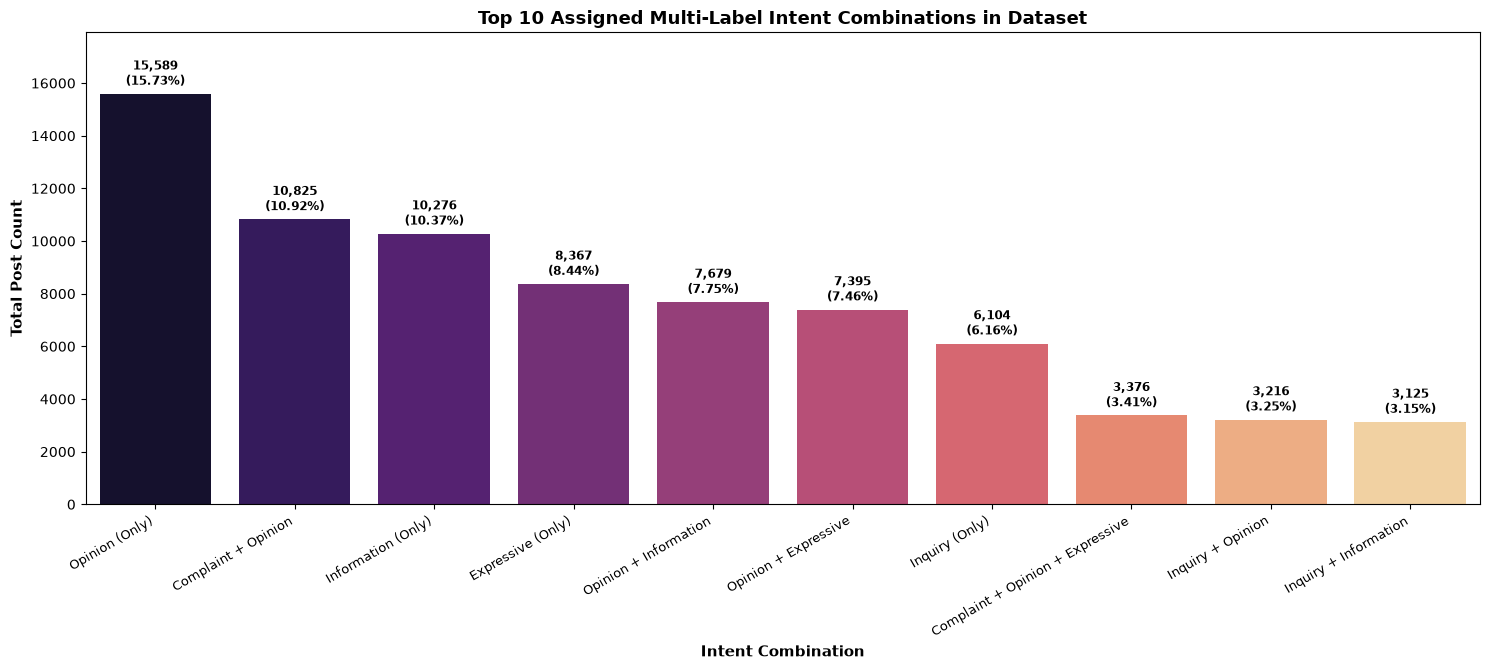

In [5]:
# Format Multi-Label Intent Combinations
def format_combo(row):
    active = [col for col in target_cols if row[col] == 1]
    if len(active) == 0:
        return 'None (0 Intents)'
    elif len(active) == 1:
        return f"{active[0]} (Only)"
    else:
        return ' + '.join(active)
    
df['intent_combination'] = df[target_cols].apply(format_combo, axis=1)
all_combinations = df['intent_combination'].value_counts()
top_10_combinations = all_combinations.head(10)

# Plot Dedicated Top 10 Intent Combinations Graph (Increased Height & Clean Axis Label)
plt.figure(figsize=(15, 6.8))
sns.barplot(x=top_10_combinations.index, y=top_10_combinations.values, palette="magma")
plt.title("Top 10 Assigned Multi-Label Intent Combinations in Dataset", fontsize=13, fontweight='bold')
plt.xlabel("Intent Combination", fontsize=11, fontweight='bold')
plt.ylabel("Total Post Count", fontsize=11, fontweight='bold')
plt.ylim(0, top_10_combinations.values[0] * 1.15)
plt.xticks(rotation=30, ha='right', fontsize=9.5)
for i, v in enumerate(top_10_combinations.values):
    plt.text(i, v + 350, f"{v:,}\n({v/len(df)*100:.2f}%)", ha='center', fontsize=8.5, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.4 Complete Breakdown of All Assigned Intent Combinations Table
Displays all unique communicative intent combinations present in the dataset with 4 decimal point precision for percentages.

In [6]:
# Display complete breakdown table with 4 decimal place precision
combo_df = pd.DataFrame({
    "Intent Combination": all_combinations.index,
    "Total Posts": all_combinations.values,
    "Percentage (%)": (all_combinations.values / len(df) * 100).round(4)
})

printmd(f"#### Complete Breakdown of All Assigned Intent Combinations in Dataset ({len(all_combinations)} Unique Combinations):")
display(combo_df.style.format({"Percentage (%)": "{:.4f}%"}))

#### Complete Breakdown of All Assigned Intent Combinations in Dataset (54 Unique Combinations):

,Intent Combination,Total Posts,Percentage (%)
0,Opinion (Only),15589,15.7299%
1,Complaint + Opinion,10825,10.9229%
2,Information (Only),10276,10.3689%
3,Expressive (Only),8367,8.4426%
4,Opinion + Information,7679,7.7484%
5,Opinion + Expressive,7395,7.4619%
6,Inquiry (Only),6104,6.1592%
7,Complaint + Opinion + Expressive,3376,3.4065%
8,Inquiry + Opinion,3216,3.2451%
9,Inquiry + Information,3125,3.1533%


### 1.5 Top 10 & Complete Breakdown of Intent Combinations Including Opinion, Inquiry, and Spam
Visualizes the 10 most common intent combinations for posts assigned each of the **Opinion**, **Inquiry**, and **Spam** labels (e.g. Opinion Only, Opinion + Inquiry, Spam + Information), followed by the complete breakdown table of all combinations for each label.

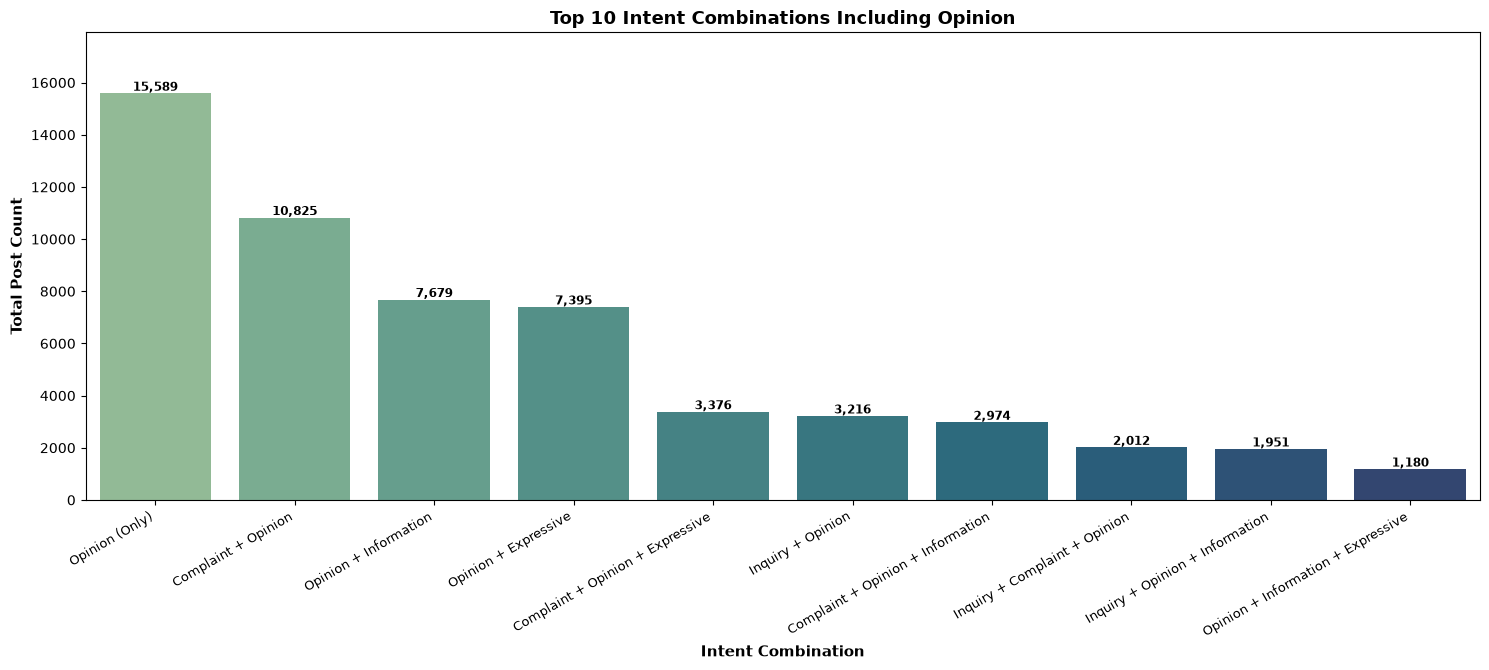

#### Complete Breakdown of Intent Combinations Including Opinion (24 Unique Combinations):

,Intent Combination,Total Posts
0,Opinion (Only),15589
1,Complaint + Opinion,10825
2,Opinion + Information,7679
3,Opinion + Expressive,7395
4,Complaint + Opinion + Expressive,3376
5,Inquiry + Opinion,3216
6,Complaint + Opinion + Information,2974
7,Inquiry + Complaint + Opinion,2012
8,Inquiry + Opinion + Information,1951
9,Opinion + Information + Expressive,1180


In [7]:
# Filter combinations containing Opinion
opinion_combinations = df[df['Opinion'] == 1]['intent_combination'].value_counts()
top_10_opinion = opinion_combinations.head(10)

# Graph: Top 10 combinations including Opinion
plt.figure(figsize=(15, 6.8))
sns.barplot(x=top_10_opinion.index, y=top_10_opinion.values, palette="crest")
plt.title("Top 10 Intent Combinations Including Opinion", fontsize=13, fontweight='bold')
plt.xlabel("Intent Combination", fontsize=11, fontweight='bold')
plt.ylabel("Total Post Count", fontsize=11, fontweight='bold')
plt.ylim(0, top_10_opinion.values[0] * 1.15)
plt.xticks(rotation=30, ha='right', fontsize=9.5)
for i, v in enumerate(top_10_opinion.values):
    plt.text(i, v + 100, f"{v:,}", ha='center', fontsize=8.5, fontweight='bold')
plt.tight_layout()
plt.show()

# Table: Complete breakdown of all combinations including Opinion (count only)
opinion_combo_df = pd.DataFrame({
    "Intent Combination": opinion_combinations.index,
    "Total Posts": opinion_combinations.values
})

printmd(f"#### Complete Breakdown of Intent Combinations Including Opinion ({len(opinion_combinations)} Unique Combinations):")
display(opinion_combo_df)

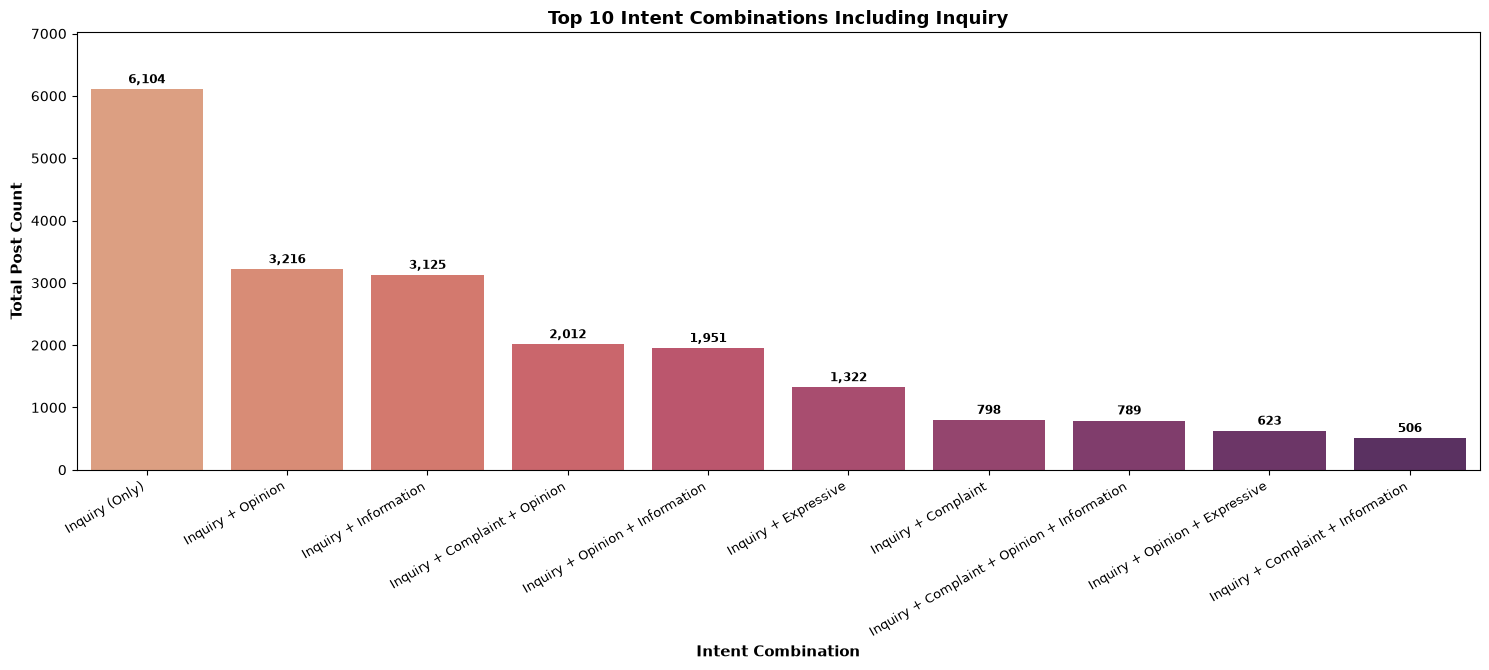

#### Complete Breakdown of Intent Combinations Including Inquiry (25 Unique Combinations):

,Intent Combination,Total Posts
0,Inquiry (Only),6104
1,Inquiry + Opinion,3216
2,Inquiry + Information,3125
3,Inquiry + Complaint + Opinion,2012
4,Inquiry + Opinion + Information,1951
5,Inquiry + Expressive,1322
6,Inquiry + Complaint,798
7,Inquiry + Complaint + Opinion + Information,789
8,Inquiry + Opinion + Expressive,623
9,Inquiry + Complaint + Information,506


In [8]:
# Filter combinations containing Inquiry
inquiry_combinations = df[df['Inquiry'] == 1]['intent_combination'].value_counts()
top_10_inquiry = inquiry_combinations.head(10)

# Graph: Top 10 combinations including Inquiry
plt.figure(figsize=(15, 6.8))
sns.barplot(x=top_10_inquiry.index, y=top_10_inquiry.values, palette="flare")
plt.title("Top 10 Intent Combinations Including Inquiry", fontsize=13, fontweight='bold')
plt.xlabel("Intent Combination", fontsize=11, fontweight='bold')
plt.ylabel("Total Post Count", fontsize=11, fontweight='bold')
plt.ylim(0, top_10_inquiry.values[0] * 1.15)
plt.xticks(rotation=30, ha='right', fontsize=9.5)
for i, v in enumerate(top_10_inquiry.values):
    plt.text(i, v + 100, f"{v:,}", ha='center', fontsize=8.5, fontweight='bold')
plt.tight_layout()
plt.show()

# Table: Complete breakdown of all combinations including Inquiry (count only)
inquiry_combo_df = pd.DataFrame({
    "Intent Combination": inquiry_combinations.index,
    "Total Posts": inquiry_combinations.values
})

printmd(f"#### Complete Breakdown of Intent Combinations Including Inquiry ({len(inquiry_combinations)} Unique Combinations):")
display(inquiry_combo_df)

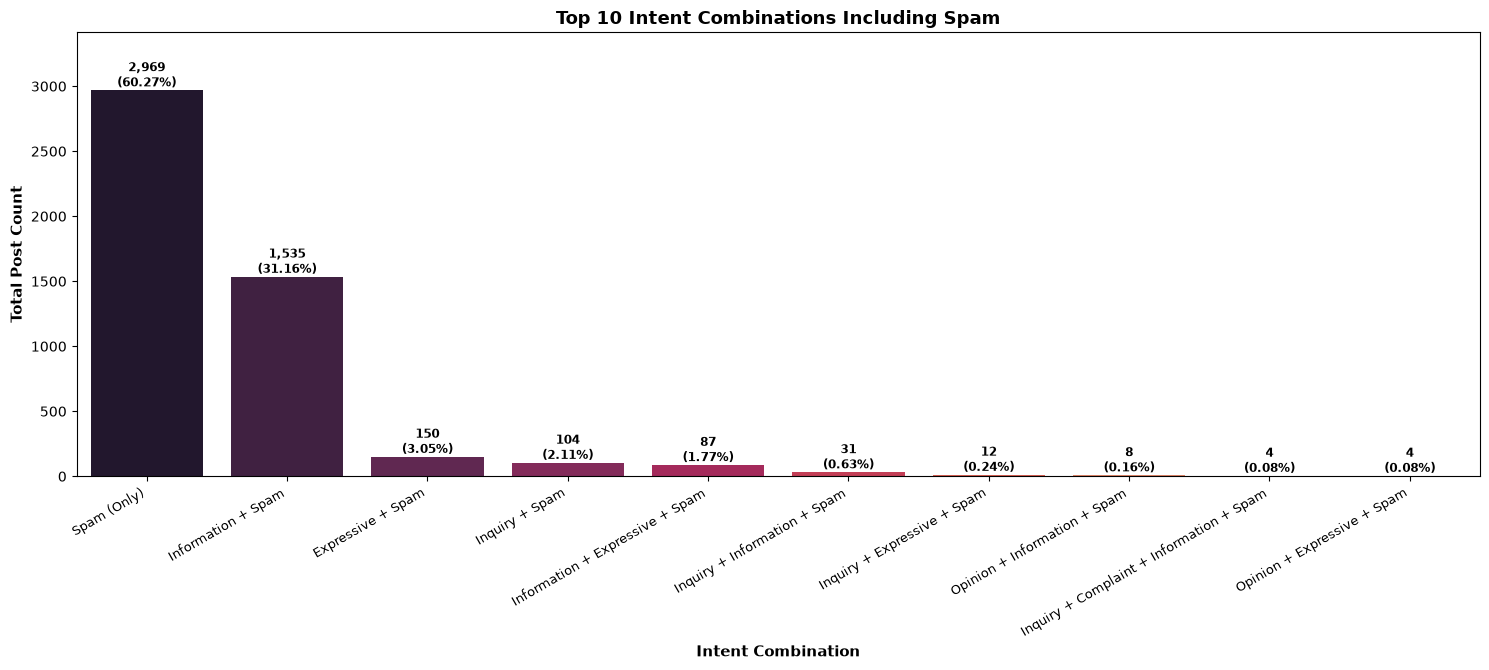

#### Complete Breakdown of Intent Combinations Including Spam (22 Unique Combinations):

,Intent Combination,Total Posts,Percentage (%)
0,Spam (Only),2969,60.2720%
1,Information + Spam,1535,31.1612%
2,Expressive + Spam,150,3.0451%
3,Inquiry + Spam,104,2.1112%
4,Information + Expressive + Spam,87,1.7661%
5,Inquiry + Information + Spam,31,0.6293%
6,Inquiry + Expressive + Spam,12,0.2436%
7,Opinion + Information + Spam,8,0.1624%
8,Inquiry + Complaint + Information + Spam,4,0.0812%
9,Opinion + Expressive + Spam,4,0.0812%


In [9]:
# Filter combinations containing Spam
spam_combinations = df[df['Spam'] == 1]['intent_combination'].value_counts()
top_10_spam = spam_combinations.head(10)

# Graph: Top 10 combinations including Spam
plt.figure(figsize=(15, 6.8))
sns.barplot(x=top_10_spam.index, y=top_10_spam.values, palette="rocket")
plt.title("Top 10 Intent Combinations Including Spam", fontsize=13, fontweight='bold')
plt.xlabel("Intent Combination", fontsize=11, fontweight='bold')
plt.ylabel("Total Post Count", fontsize=11, fontweight='bold')
plt.ylim(0, top_10_spam.values[0] * 1.15)
plt.xticks(rotation=30, ha='right', fontsize=9.5)
for i, v in enumerate(top_10_spam.values):
    plt.text(i, v + 30, f"{v:,}\n({v/df['Spam'].sum()*100:.2f}%)", ha='center', fontsize=8.5, fontweight='bold')
plt.tight_layout()
plt.show()

# Table: Complete breakdown of all combinations including Spam (count + percentage)
spam_combo_df = pd.DataFrame({
    "Intent Combination": spam_combinations.index,
    "Total Posts": spam_combinations.values,
    "Percentage (%)": (spam_combinations.values / df['Spam'].sum() * 100).round(4)
})

printmd(f"#### Complete Breakdown of Intent Combinations Including Spam ({len(spam_combinations)} Unique Combinations):")
display(spam_combo_df.style.format({"Percentage (%)": "{:.4f}%"}))

### Preprocessing Change Inspection Helper (Visual Colored HTML Diff View)
We define `show_step_diff()` using Python's `difflib.SequenceMatcher` and `html.escape()` to render a clean, left-aligned side-by-side HTML diff table:
- **Left-Aligned Text**: All text content is explicitly aligned to the left.
- **HTML Escaped**: Raw HTML/iframe/media tags in posts are safely escaped as plain text to prevent accidental video embeds or formatting distortions.
- **Strict Column Proportions**: Row ID (8%), BEFORE (46%), AFTER (46%).
- **Guaranteed 5-Sample Representation**: Prioritizes concise representative samples (< 250 chars), but always fills up to 5 full samples by pulling from the modified rows if fewer than 5 short posts exist.
- **Visual Highlighting**: Removed tokens in red strikethrough, normalized tokens in bold green.

In [10]:
import difflib
import html

def show_step_diff(prev_series, curr_series, step_name):
    diff_mask = prev_series.astype(str).str.split() != curr_series.astype(str).str.split() # ignore pure spacing differences
    total_affected = diff_mask.sum()
    printmd(f"**[{step_name}]** Rows updated: `{total_affected:,}` ({total_affected/len(prev_series)*100:.2f}%)")
    
    if total_affected == 0:
        printmd("_No rows modified in this step._")
        return
        
    changed_df = pd.DataFrame({
        "before": prev_series[diff_mask],
        "after": curr_series[diff_mask]
    })
    
    # Prioritize concise representative posts (< 250 chars), but always guarantee 5 samples if available
    short_samples = changed_df[changed_df["before"].astype(str).str.len() < 250]
    remaining_samples = changed_df[~changed_df.index.isin(short_samples.index)]
    sample_df = pd.concat([short_samples, remaining_samples]).head(5) if len(changed_df) >= 5 else changed_df
    
    html_rows = []
    for idx, row in sample_df.iterrows():
        b_words = str(row["before"]).split()
        a_words = str(row["after"]).split()
        matcher = difflib.SequenceMatcher(None, b_words, a_words)
        
        b_out, a_out = [], []
        for tag, i1, i2, j1, j2 in matcher.get_opcodes():
            b_chunk = html.escape(" ".join(b_words[i1:i2]))
            a_chunk = html.escape(" ".join(a_words[j1:j2]))
            
            if tag == 'equal':
                b_out.append(b_chunk)
                a_out.append(a_chunk)
            elif tag == 'replace':
                b_out.append(f"<span style='background-color:#ffebee; color:#c62828; text-decoration:line-through;'>{b_chunk}</span>")
                a_out.append(f"<span style='background-color:#e8f5e9; color:#2e7d32; font-weight:bold;'>{a_chunk}</span>")
            elif tag == 'delete':
                b_out.append(f"<span style='background-color:#ffebee; color:#c62828; text-decoration:line-through;'>{b_chunk}</span>")
            elif tag == 'insert':
                a_out.append(f"<span style='background-color:#e8f5e9; color:#2e7d32; font-weight:bold;'>{a_chunk}</span>")
                
        html_rows.append(f'''
        <tr style="border-bottom: 1px solid #e0e0e0;">
            <td style="padding: 8px 6px; font-weight: bold; vertical-align: top; width: 8%; color: #555; text-align: left; word-break: break-word;">Row {idx}</td>
            <td style="padding: 8px 10px; vertical-align: top; width: 46%; font-family: monospace; font-size: 12px; line-height: 1.5; text-align: left; word-break: break-word; white-space: normal;">{' '.join(b_out)}</td>
            <td style="padding: 8px 10px; vertical-align: top; width: 46%; font-family: monospace; font-size: 12px; line-height: 1.5; text-align: left; word-break: break-word; white-space: normal;">{' '.join(a_out)}</td>
        </tr>
        ''')
        
    table_html = f'''
    <table style="table-layout: fixed; width: 100%; border-collapse: collapse; border: 1px solid #ccc; margin-top: 8px; margin-bottom: 16px;">
        <thead>
            <tr style="background-color: #f5f5f5; border-bottom: 2px solid #ccc; text-align: left;">
                <th style="width: 8%; padding: 8px 6px; font-size: 12px; text-align: left;">Row ID</th>
                <th style="width: 46%; padding: 8px 10px; font-size: 12px; text-align: left;">BEFORE (Prior Step)</th>
                <th style="width: 46%; padding: 8px 10px; font-size: 12px; text-align: left;">AFTER (Modified Step)</th>
            </tr>
        </thead>
        <tbody>
            {''.join(html_rows)}
        </tbody>
    </table>
    '''
    display(HTML(table_html))

# Initialize clean_text column
df['clean_text'] = df['text'].copy()

# Step 2: Remove Lowyat Quotes, BBCode, Signatures, and HTML
Forum-specific noise such as nested quote blocks, spoilers, images, BBCode tags, Lowyat edit signatures, and strict HTML markup are stripped one by one.

### 2.1 Remove Quote Blocks & Quote Headers
Quotes contain text originally written by other users, which distorts the current user's intent. Both `[quote]...[/quote]` blocks and `QUOTE(...)` headers are stripped.

In [11]:
import re

def remove_quote_blocks(text):
    if not isinstance(text, str): return ""

    # Remove complete BBCode quote blocks: [quote]...[/quote]
    text = re.sub(r'\[quote(?:=[^\]]*)?\][\s\S]*?\[/quote\]', ' ', text, flags=re.IGNORECASE)
    
    # Remove standard stray/closing tags: [quote], [/quote], [quote=...]
    text = re.sub(r'\[/?quote(?:=[^\]]*)?\]', ' ', text, flags=re.IGNORECASE)
    
    # Catch malformed unclosed tags like [/quote without the ']' bracket (Row 3218, Row 63659)
    text = re.sub(r'\[/?quote\b', ' ', text, flags=re.IGNORECASE)
    
    # Remove QUOTE(...) header strings
    text = re.sub(r'QUOTE\s*\([^\)]*?\)', ' ', text, flags=re.IGNORECASE)

    return text

# Apply Step 2.1
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(remove_quote_blocks)
show_step_diff(prev_step, df['clean_text'], "Step 2.1: Remove Quote Blocks & Headers")

**[Step 2.1: Remove Quote Blocks & Headers]** Rows updated: `44,791` (45.20%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 4,"QUOTE(ahmad92 @ Dec 17 2022, 01:03 PM)Oi apek, i bunuh empat orang with low health in overpass you tak post. Hahaha Manada. Tatau tatau 🤣🤣🤣🤣🤣🤣","Oi apek, i bunuh empat orang with low health in overpass you tak post. Hahaha Manada. Tatau tatau 🤣🤣🤣🤣🤣🤣"
Row 5,"QUOTE(Angry Clerk @ Mar 10 2023, 05:50 PM)yes non can join, like DPPH PAS, but can't be AJK Why aim high to be AJK? Setakat bell boys or waiters on site should be enough","yes non can join, like DPPH PAS, but can't be AJK Why aim high to be AJK? Setakat bell boys or waiters on site should be enough"
Row 17,"QUOTE(ZeaXG @ Apr 23 2023, 11:38 AM)RIP hometown of roti canai Roti canai makanan tradisional kita",RIP hometown of roti canai Roti canai makanan tradisional kita
Row 22,"QUOTE(iGamer @ Jan 31 2023, 09:20 AM)No outstanding loan, net saver cukur no hutang hnnngghhh","No outstanding loan, net saver cukur no hutang hnnngghhh"
Row 25,"QUOTE(hotdayum @ Apr 15 2023, 09:24 PM)Now that you've come in, tered ni sah What did I do","Now that you've come in, tered ni sah What did I do"


### 2.2 Remove Spoilers
Lowyat spoiler blocks `[spoiler]...[/spoiler]` and click-to-show spoiler prompts are stripped.

In [12]:
def remove_spoilers(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'»\s*Click to show Spoiler.*?«', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\[spoiler(?:=[^\]]*)?\][\s\S]*?\[/spoiler\]', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\[/?spoiler(?:=[^\]]*)?\]', ' ', text, flags=re.IGNORECASE)
    return text

# Apply Step 2.2
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(remove_spoilers)
show_step_diff(prev_step, df['clean_text'], "Step 2.2: Remove Spoilers")

**[Step 2.2: Remove Spoilers]** Rows updated: `583` (0.59%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 719,"i want see bikini teteks haram, rarer than spotting a yeti » Click to show Spoiler - click again to hide... « Malaysia bila? jnCvkPbG7i8 This post has been edited by Freshmeat21: Mar 20 2023, 06:48 PM","i want see bikini teteks haram, rarer than spotting a yeti Malaysia bila? jnCvkPbG7i8 This post has been edited by Freshmeat21: Mar 20 2023, 06:48 PM"
Row 1514,"Exactly. blame Benefon Don’t hamsup me , i begging you 🥺🥺🥺🥺 » Click to show Spoiler - click again to hide... «","Exactly. blame Benefon Don’t hamsup me , i begging you 🥺🥺🥺🥺"
Row 1553,LULUS ! i got RM1600! » Click to show Spoiler - click again to hide... «kidding!,LULUS ! i got RM1600! kidding!
Row 2017,» Click to show Spoiler - click again to hide... «https://pnrtscr.com/kqrkc7 that's my old friend right there! looks so much better now,https://pnrtscr.com/kqrkc7 that's my old friend right there! looks so much better now
Row 2634,Some cheapy stash for these 2 week..... » Click to show Spoiler - click again to hide... « how cheap is cheap bro?,Some cheapy stash for these 2 week..... how cheap is cheap bro?


### 2.3 Remove Images & Code Blocks
BBCode image tags `[IMG]...[/IMG]` and code blocks `[code]...[/code]` are stripped.

In [13]:
def remove_images_and_code(text):
    if not isinstance(text, str):
        return ""
    
    # Full Image blocks: catches [IMG]...[/IMG], CODE[IMG]...[/IMG], [/IMG]...[/IMG], and img]...[/img]
    text = re.sub(r'(?:CODE\s*)?\[?/?IMG\][\s\S]*?\[/?IMG\]', ' ', text, flags=re.IGNORECASE)
    
    # Code blocks: [code]...[/code]
    text = re.sub(r'\[code(?:=[^\]]*)?\][\s\S]*?\[/code\]', ' ', text, flags=re.IGNORECASE)
    
    # Stray / standalone tags: [img], [/img], img], [code], [/code]
    text = re.sub(r'\[?/?img\]', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\[/?code(?:=[^\]]*)?\]', ' ', text, flags=re.IGNORECASE)
    
    # Stray CODE[ prefixes
    text = re.sub(r'\bCODE\[', ' ', text, flags=re.IGNORECASE)

    # Stray targets uppercase 'CODE' when immediately followed by a non-space character
    text = re.sub(r'\bCODE(?=[^\s])', ' ', text)
    
    return text

# Apply Step 2.3
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(remove_images_and_code)
show_step_diff(prev_step, df['clean_text'], "Step 2.3: Remove Images & Code Blocks")

**[Step 2.3: Remove Images & Code Blocks]** Rows updated: `40` (0.04%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 2727,What's the point of this thread. CODEWhy are you all so sick? Every where malay malay malay. Not enough? Even in LYN also wanna start your own Malay group? WTH!,What's the point of this thread. Why are you all so sick? Every where malay malay malay. Not enough? Even in LYN also wanna start your own Malay group? WTH!
Row 26776,"[/IMG]https://images.trvl-media.com/lodging/1000000/910000/904300/904240/3514ecfb.jpg[/IMG] This post has been edited by plouffle0789: Apr 20 2023, 12:29 AM","This post has been edited by plouffle0789: Apr 20 2023, 12:29 AM"
Row 67961,img]https://en.meming.world/images/en/thumb/f/fd/Oof_Stones.jpg/300px-Oof_Stones.jpg[/img] you missed that CODE[,you missed that
Row 895,"CODE[IMG]https://forum.lowyat.net/uploads//attach-79/post-526479-1652403245.gif[/IMG] CODE[IMG]https://c.tenor.com/qK4uJn-NnTUAAAAd/first-time-james-franco.gif[/IMG] CODE[IMG]https://i.kym-cdn.com/photos/images/newsfeed/001/590/295/cb3.gif[/IMG] CODE[IMG]https://media.giphy.com/media/EEAi8hL317CRccUD7e/giphy-downsized-large.gif[/IMG] CODE[IMG]https://cdn.acidcow.com/uploads/posts/2022-05/1652822253_18.gif[/IMG] This post has been edited by empstar2: May 18 2022, 04:29 PM","This post has been edited by empstar2: May 18 2022, 04:29 PM"
Row 2898,= CODE[IMG]https://media.giphy.com/media/obwVjuj7WGZEI/giphy.gif[/IMG] = CODE[IMG]http://3.bp.blogspot.com/-vdKqjrU5UFY/T7Bxpg7IDRI/AAAAAAAAgRw/U2AQ8A35lR4/s1600/FGMotoBalanceFail.gif[/IMG] = CODE[IMG]http://img0.joyreactor.com/pics/post/kid-boobs-gif-lucky-1268260.gif[/IMG] = CODE[IMG]https://funnyasduck.net/wp-content/uploads/2014/06/funny-pictures-ferrett-in-a-jar-surprise-animated-gif.gif[/IMG] = CODE[IMG]https://media.giphy.com/media/1fJXf1Ut9tOMg/giphy.gif[/IMG] = CODE[IMG]https://funnyasduck.net/wp-content/uploads/2013/02/funny-man-holding-chicken-run-away-animated-gif-pics.gif[/IMG] = CODE[IMG]https://www.planetdan.net/pics/misc/piginapoke.gif[/IMG] = CODE[IMG]http://img0.joyreactor.com/pics/post/running-finish-fail-gif-1975206.gif[/IMG],= = = = = = = =


### 2.4 Remove Video, Attachments & Links BBCode
Strips BBCode wrappers for YouTube, embedded videos, Lowyat attachment IDs, and email tags.

In [14]:
def remove_media_bbcode(text):
    if not isinstance(text, str): 
        return ""
    
    # YouTube & Video complete blocks (handles malformed brackets like YOUTUBE]...[/YOUTUBE)
    text = re.sub(r'\[?YOUTUBE(?:=[^\]\n]*)?\]?[\s\S]*?\[/?YOUTUBE\]?', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\[?VIDEO\s*(?:=[^\]\n]*)?\]?[\s\S]*?\[/?VIDEO\s*\]?', ' ', text, flags=re.IGNORECASE)
    
    # Standalone / Unclosed YouTube & Video tags
    text = re.sub(r'\[/?(?:youtube|video)\s*(?:=[^\]\n]*)?\]?', ' ', text, flags=re.IGNORECASE)
    
    # URL & Linkz tags (handles complete tags and unclosed tags like `[/url` missing `]`)
    text = re.sub(r'\[/?url(?:=[^\]\n]*)?\]?', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\[/?linkz(?:=[^\]\n]*)?\]?', ' ', text, flags=re.IGNORECASE)
    
    # Attachments & Attachment IDs
    text = re.sub(r'\[attachmentid\s*=\s*\d+\]?', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\[/?attachment(?:=[^\]\n]*)?\]?', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'Attached\s+(?:thumbnail|image|file|picture)\(s\)', ' ', text, flags=re.IGNORECASE)
    
    # Email tags
    text = re.sub(r'\[/?email(?:=[^\]\n]*)?\]?', ' ', text, flags=re.IGNORECASE)
    
    return text

# Apply Step 2.4
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(remove_media_bbcode)
show_step_diff(prev_step, df['clean_text'], "Step 2.4: Remove Media & Attachment BBCode")

**[Step 2.4: Remove Media & Attachment BBCode]** Rows updated: `258` (0.26%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 265,ok.on da plane..wish me safelly mendarat yer.... Attached thumbnail(s),ok.on da plane..wish me safelly mendarat yer....
Row 788,My T bone huat lai Attached thumbnail(s),My T bone huat lai
Row 803,"https://www.met.gov.my/forecast/weather/town/ based on my different source, it is NOT GOING TO HIT 30C TODAY. Attached thumbnail(s)","https://www.met.gov.my/forecast/weather/town/ based on my different source, it is NOT GOING TO HIT 30C TODAY."
Row 873,damn the embed title [VIDEO ] thought got ahem video,damn the embed title thought got ahem video
Row 1690,"[YOUTUBE=https://www.youtube.com/watch?v=DuWEEKeJLMI] Cocaine Bear Malaysia ada? DuWEEKeJLMI This post has been edited by MaybachS600: Feb 9 2023, 02:09 PM","Cocaine Bear Malaysia ada? DuWEEKeJLMI This post has been edited by MaybachS600: Feb 9 2023, 02:09 PM"


### 2.5 Remove BBCode Text Formatting Tags
Strips bold `[b]`, italic `[i]`, underline `[u]`, strikethrough `[s]`, color `[color]`, size `[size]`, and font `[font]` tags while retaining inner content words.

In [15]:
def remove_formatting_tags(text):
    if not isinstance(text, str):
        return ""
    
    # Multi-character tags: [color=...], [size=...], [font=...]
    text = re.sub(r'\[/?(?:color|size|font)(?:=[^\]]*)?\]', ' ', text, flags=re.IGNORECASE)
    
    # Closing tags are ALWAYS BBCode (cleans [/b]Chicken without skipping)
    text = re.sub(r'\[/(?:b|i|u|s)\]', ' ', text, flags=re.IGNORECASE)
    
    # Opening tags: [b], [i], [u] are stripped; [s] only stripped if not an editorial prefix like '[s]ince'
    text = re.sub(r'\[(?:b|i|u)\]', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\[s\](?![a-z])', ' ', text, flags=re.IGNORECASE)
    
    # Malformed tag typos like ]b], ]i]
    text = re.sub(r'\][biuses]\]', ' ', text, flags=re.IGNORECASE)
    
    return text

# Apply Step 2.5
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(remove_formatting_tags)
show_step_diff(prev_step, df['clean_text'], "Step 2.5: Remove Text Formatting Tags")

**[Step 2.5: Remove Text Formatting Tags]** Rows updated: `13` (0.01%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 93771,There's shopee farm group in fb so that we can water each other’s plant . welcome to join ^^ #shopeefarm https://www.facebook.com/groups/32164365259...timonster=share Shopee Farm Malaysia[COLOR=blue] thanks thanks,There's shopee farm group in fb so that we can water each other’s plant . welcome to join ^^ #shopeefarm https://www.facebook.com/groups/32164365259...timonster=share Shopee Farm Malaysia thanks thanks
Row 5102,"Shopee Shake - FULL Link removed - full`! [i]Shopee Quiz Play and win up to 1,000,000 Shopee coins from Shopee Quiz! Play now! https://games.shopee.com.my/universal-link/...2BofHcMvaYbA%3D Lazada Come join to get your share of rebates!! New users will receive RM7!!! https://s.lazada.com.my/s.uW0p This post has been edited by starry-starry: Apr 26 2019, 02:08 PM","Shopee Shake - FULL Link removed - full`! Shopee Quiz Play and win up to 1,000,000 Shopee coins from Shopee Quiz! Play now! https://games.shopee.com.my/universal-link/...2BofHcMvaYbA%3D Lazada Come join to get your share of rebates!! New users will receive RM7!!! https://s.lazada.com.my/s.uW0p This post has been edited by starry-starry: Apr 26 2019, 02:08 PM"
Row 19333,"Tldr: The brochure promised 5% to 9% return on investment but instead it was negative 5% for me, so you pandai-pandai la gamble your money. I'm currently on an investment link plan by one of the big ones. As far as I understand: The amount of money I pay in premiums buy a certain number of unit trust managed by the insurance company. The number of units I get depends on the current price of that trust. The insurance company will then minus from these units the cost of my medical card, management fees and sales commissions. The amount they minus will change based on the cost of your medical insurance etc. The amount they charge you is fixed in RM, whereas the amount of money in your account depends on the price of the unit trust. From the very start, they charge you the full amount. So even if your unit trust fail completely, every year you are paying enough to keep you covered. But you will be losing alot of money for nothing. If your unit trust does very well, then there is a chance you can still have coverage for few years even if you don't pay even one sen. Depends how many unit trust in your account and the price of each in RM. For me, the unit trust that I bought with this insurance hasn't been doing well. In the brochure they promise me 5-9%, whereas this one was negative 5. So I'm going for standalone medical instead and I invest in something that gives guaranteed returns, like a regular bank. GE boy, why you no explain fake info by the brochure, stop blaming agents liao. When brochure promises so, why blame agent???? So clever, later, one day, will blame client no read fine prints ah, didn't read, just sign, and listen agents talk cock sing song play ping pong ah...Ah hahahahaha. Also, eventually all cash value in ILP will become zero due to increasing insurance charges. How fast it goes to zero depends on the sustainability of the policy which is designed by your agent. GE boy, if so, why called investment linked product. You know what is investment? Investment means hopefully one day when reach ah gong ah ma time, the money grows to be bigger. If it becomes zero, then should call IBZ product = INVESTMENT BECOMES ZERO product. Like that won't sounds deceitful mah. Oh wait, you may say some UT does well. But But. I am addressing those that EVENTUALLY THEY WILL ALL BECOME ZERO VALUE PRODUCT. Why still call ILP? ""Insurance agents end of the day want their commission, nothing about you getting the right lifestyle of best suited insurance/medical card""[I] Even can praise smokers saying they will get best treatment because they are covered well, lol. Where is the please stop smoking advice.","Tldr: The brochure promised 5% to 9% return on investment but instead it was negative 5% for me, so you pandai-pandai la gamble you

### 2.6 Remove Lowyat Edit Signatures & Moderator Notices
Strips auto-generated trailing lines like `This post has been edited by...` and moderator redactions `<...removed...>`.

In [16]:
def remove_signatures_and_redactions(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'This post has been edited by.*?(?=\n|$)', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'<[a-zA-Z0-9\s_\-\/]+removed[a-zA-Z0-9\s_\-]*>', ' ', text, flags=re.IGNORECASE)
    return text

# Apply Step 2.6
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(remove_signatures_and_redactions)
show_step_diff(prev_step, df['clean_text'], "Step 2.6: Remove Signatures & Moderator Notices")

**[Step 2.6: Remove Signatures & Moderator Notices]** Rows updated: `8,064` (8.14%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 11,". This post has been edited by TanahGagal: Feb 5 2023, 09:28 PM",.
Row 16,Ayam don't have thinnest skin known in quantum universe unlike some <racial reference removed>.,Ayam don't have thinnest skin known in quantum universe unlike some .
Row 33,"Think so. I am also confused when first reading the article. World first? Trans man marry Trans woman But trans man is the one get pregnant This post has been edited by diffyhelman2: Apr 10 2023, 03:22 PM",Think so. I am also confused when first reading the article. World first? Trans man marry Trans woman But trans man is the one get pregnant
Row 37,"why report from Bangal land ? This post has been edited by ycs: Apr 28 2023, 11:19 AM",why report from Bangal land ?
Row 75,"I want to withdraw all my epf when you are 55 years old, you can withdraw all your money. This post has been edited by wkn: Apr 4 2023, 09:17 AM","I want to withdraw all my epf when you are 55 years old, you can withdraw all your money."


### 2.7 Remove Strict HTML Tags
Removes leftover raw HTML elements (`<br>`, `<a>`, `<div>`, `<p>`, `<span>`, `<table>`, etc.).

In [17]:
def remove_html_tags(text):
    if not isinstance(text, str):
        return ""
    
    # Remove complete iframe, script, and style blocks
    text = re.sub(r'<(?:iframe|script|style)\b[^>]*>[\s\S]*?</(?:iframe|script|style)>', ' ', text, flags=re.IGNORECASE)
    
    # Remove standard HTML tags (avoids single-letter race/slang tags like <C>, <M>, <I>, <S>)
    text = re.sub(r'</?(?:div|br|p|span|table|tbody|tr|td|th|thead|tfoot|ul|ol|li|img|a|strong|em|hr|blockquote|font|button|input|form)\b[^>]*>', ' ', text, flags=re.IGNORECASE)
    
    return text

# Apply Step 2.7
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(remove_html_tags)
show_step_diff(prev_step, df['clean_text'], "Step 2.7: Remove Strict HTML Tags")

**[Step 2.7: Remove Strict HTML Tags]** Rows updated: `7` (0.01%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 9330,"<a href='https://pictr.com/images/2022/03/02/BWNuBJ.md.png' target='_blank'>https://pictr.com/images/2022/03/02/BWNuBJ.md.png </a> My parcel is also stuck in J&T, sad...","https://pictr.com/images/2022/03/02/BWNuBJ.md.png My parcel is also stuck in J&T, sad..."
Row 96112,"<iframe width=""640"" height=""480"" src=""http://www.youtube.com/embed/9Z6Q0X60rmo"" frameborder=""0"" allow=""accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture"" allowfullscreen></iframe>",
Row 22378,"Hi, I applied as new application. After completing everything n semak again , The status is Permohonan Diterima but there's this Kemaskini Permohonan right below the Permohonan Diterima. I've fill up every detail but no matter how many times I did it the Kemaskini Permohonan is always there. Did I left out something? So I tried going to BSH n check, in bsh it says Keputusan kelulusan akan dimaklumkan .. Btw I registered in BPN website on 4/4/2020 Below are the images of my status Please advise. Thank you <a href='https://pictr.com/images/2020/04/07/5Rbc79.md.jpg' target='_blank'>https://pictr.com/images/2020/04/07/5Rbc79.md.jpg </a> <a href='https://pictr.com/images/2020/04/07/5RbvCg.md.jpg' target='_blank'>https://pictr.com/images/2020/04/07/5RbvCg.md.jpg </a> Hi, Mine status also same as yours and my application is on 3/4/2020. I guess still have to wait for it to lulus","Hi, I applied as new application. After completing everything n semak again , The status is Permohonan Diterima but there's this Kemaskini Permohonan right below the Permohonan Diterima. I've fill up every detail but no matter how many times I did it the Kemaskini Permohonan is always there. Did I left out something? So I tried going to BSH n check, in bsh it says Keputusan kelulusan akan dimaklumkan .. Btw I registered in BPN website on 4/4/2020 Below are the images of my status Please advise. Thank you https://pictr.com/images/2020/04/07/5Rbc79.md.jpg https://pictr.com/images/2020/04/07/5RbvCg.md.jpg Hi, Mine status also same as yours and my application is on 3/4/2020. I guess still have to wait for it to lulus"
Row 34135,Ban la. <a href='https:// /2022/04/26/certain-micro-mobility-vehicles-banned-on-malaysian-roads/' target='_blank'>https:// /2022/04/26/certain-micr...alaysian-roads/</a> Pauly tan site. Confirm correct one. not entirely banned - https://www.wapcar.my/news/mot-clarifies-es...lic-roads-52610,Ban la. https:// /2022/04/26/certain-micr...alaysian-roads/ Pauly tan site. Confirm correct one. not entirely banned - https://www.wapcar.my/news/mot-clarifies-es...lic-roads-52610
Row 47916,"<iframe src=""https://www.facebook.com/plugins/video.php?height=476&href=https%3A%2F%2Fwww.facebook.com%2FBangkokBoy88%2Fvideos%2F855735269021294%2F&show_text=false&width=380&t=0"" width=""380"" height=""476"" style=""border:none;overflow:hidden"" scrolling=""no"" frameborder=""0"" allowfullscreen=""true"" allow=""autoplay; clipboard-write; encrypted-media; picture-in-picture; web-share"" allowFullScreen=""true""></iframe> This is what we need most Malaysian to learn. Dont suka2 parking hit ppl then run away like dog you need to learn too",This is what we need most Malaysian to learn. Dont suka2 parking hit ppl then run away like dog you need to learn too


# Step 3: Special Element Masking
Variable numerical, temporal, contact, and hyperlink expressions are mapped into normalized placeholder tokens (`EMAILTOKEN`, `URLTOKEN`, `PHONETOKEN`, `NRICTOKEN`, `PRICETOKEN`, `DATETOKEN`, `TIMETOKEN`) to capture communicative intent without vocabulary fragmentation.

### 3.1 Mask Email Addresses
Replaces email with `EMAILTOKEN`

In [18]:
def mask_emails(text):
    if not isinstance(text, str):
        return ""
    
    # Standard email address pattern
    text = re.sub(r'\b[A-Za-z0-9._%+\-*]+@[A-Za-z0-9.\-*]+\.[A-Za-z]{2,}\b', ' EMAILTOKEN ', text, flags=re.IGNORECASE)
    
    return text

# Apply Step 3.1
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(mask_emails)
show_step_diff(prev_step, df['clean_text'], "Step 3.1: Mask Emails")

**[Step 3.1: Mask Emails]** Rows updated: `24` (0.02%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 36766,Anyone know what is the contact email for lazada? I tried this didnt work : asklaz@lazada.com.my,Anyone know what is the contact email for lazada? I tried this didnt work : EMAILTOKEN
Row 62099,"why not just call or email them to confirm? TOLL FREE 1800 222 ZOO (900) HOTLINE : 06 2323 900 ENQUIRIES : zoomelakasales@gmail.com good idea, thanks","why not just call or email them to confirm? TOLL FREE 1800 222 ZOO (900) HOTLINE : 06 2323 900 ENQUIRIES : EMAILTOKEN good idea, thanks"
Row 69505,"Hi Sifus, Is the asklaz@lazada.com.my email address still in service? I think no. Need trigger from livechat, they email u then only u can reply from there. Correct me if ayam wrong","Hi Sifus, Is the EMAILTOKEN email address still in service? I think no. Need trigger from livechat, they email u then only u can reply from there. Correct me if ayam wrong"
Row 83771,"3 slots available. RM50 for a year. Anyone interested kindly email me, brandomjs@gmail.com as I don't usually check here. I will send you the link first, once you successfully added in the subscription then bank in to me. Full house.","3 slots available. RM50 for a year. Anyone interested kindly email me, EMAILTOKEN as I don't usually check here. I will send you the link first, once you successfully added in the subscription then bank in to me. Full house."
Row 91438,"M***w***g.****@gmail.com, email as id lol. Don't do it next time.","EMAILTOKEN , email as id lol. Don't do it next time."


### 3.2 Mask URLs & Web Hyperlinks
Replaces HTTP/HTTPS URLs and `www.` domain links with `URLTOKEN`.

In [19]:
def mask_urls(text):
    if not isinstance(text, str):
        return ""
    
    # Scheme-based URLs (http, https, hxxp, ftp)
    text = re.sub(r'(?:https?|hxxps?|ftp)://[^\s<>"]+', ' URLTOKEN ', text, flags=re.IGNORECASE)
    
    # www. prefixed links
    text = re.sub(r'(?<![a-zA-Z0-9])www\.[^\s<>"]+', ' URLTOKEN ', text, flags=re.IGNORECASE)
    
    # Known shortlinks / app links with or without paths
    text = re.sub(r'\b(?:t\.me|goo\.gl|bit\.ly|tinyurl\.com|pictr\.com)(?:/[^\s<>"]*)?', ' URLTOKEN ', text, flags=re.IGNORECASE)
    
    # Domain label helper: strictly forbids consecutive dots (ellipses)
    label = r'[a-zA-Z0-9](?:[a-zA-Z0-9-]{0,61}[a-zA-Z0-9])?'
    
    # Malaysian compound domains (.com.my, .edu.my, .gov.my, .org.my, .net.my)
    my_compound = rf'(?<![@a-zA-Z0-9._-])\b(?:{label}\.)+(?:com|edu|gov|org|net)\.my(?:/[^\s<>"]*)?'
    text = re.sub(my_compound, ' URLTOKEN ', text, flags=re.IGNORECASE)
    
    # Standard gTLDs (.com, .org, .net, .edu, .gov, .io, .ai, .app)
    gtlds = rf'(?<![@a-zA-Z0-9._-])\b(?:{label}\.)+(?:com|org|net|edu|gov|io|ai|app)(?:/[^\s<>"]*)?'
    text = re.sub(gtlds, ' URLTOKEN ', text, flags=re.IGNORECASE)
    
    # Generic/short TLDs (e.g. .to, .me, .co) ONLY when followed by an explicit path
    generic_paths = rf'(?<![@a-zA-Z0-9._-])\b(?:{label}\.)+[a-zA-Z]{{2,}}/[^\s<>"]+'
    text = re.sub(generic_paths, ' URLTOKEN ', text, flags=re.IGNORECASE)
    
    return text

# Apply Step 3.2
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(mask_urls)
show_step_diff(prev_step, df['clean_text'], "Step 3.2: Mask URLs")

**[Step 3.2: Mask URLs]** Rows updated: `9,821` (9.91%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 1,Shake shake 5pm https://games.shopee.com.my/universal-link/...95515050372?f=1,Shake shake 5pm URLTOKEN
Row 8,https://s.lazada.com.my/s.vKM8 Instant cash out,URLTOKEN Instant cash out
Row 19,https://s.lazada.com.my/s.ZXbTx Can you join my group for cash..,URLTOKEN Can you join my group for cash..
Row 58,https://s.lazada.com.my/s.I9YV 1 more to go,URLTOKEN 1 more to go
Row 70,https://games.shopee.com.my/universal-link/...54294213855?f=1 1 MOREEE,URLTOKEN 1 MOREEE


### 3.3 Mask Phone Numbers
Robustly detects and replaces Malaysian mobile and landline telephone numbers, as well as international contact numbers (using Google's `phonenumbers` library with strict prefix regex) with `PHONETOKEN`. Large standalone numbers (e.g. 140 million) and alphanumeric reference IDs are protected from false masking.

In [20]:
from phonenumbers import PhoneNumberMatcher

def mask_phone_numbers(text, regions=("MY", "SG", "US", "ID", "TH")):
    if not isinstance(text, str):
        return ""
    if not text.strip():
        return text
    
    # Parse via Google phonenumbers library across relevant regions
    for region in regions:
        try:
            matches = list(PhoneNumberMatcher(text, region))
            for match in reversed(matches):
                text = text[:match.start] + " PHONETOKEN " + text[match.end:]
        except Exception:
            pass
    
    # Strict Malaysian mobile & landline + international regex (with +)
    text = re.sub(r'\b(?:\+?6?01)[0-46-9][-\s]?[0-9]{7,8}\b', ' PHONETOKEN ', text)
    text = re.sub(r'\b(?:\+?6?0[3-9])[-\s]?[0-9]{6,8}\b', ' PHONETOKEN ', text)
    text = re.sub(r'\+\d{1,3}[-\s]?\d{1,4}[-\s]?\d{4,8}\b', ' PHONETOKEN ', text)
    
    # Malaysian & International Toll-Free / Hotlines (1-800, 1800, 1-300, 800, 888, etc.)
    text = re.sub(r'\b(?:1[-.\s]?)?(?:800|888|877|866|855|844|833|1800|1300)[-.\s]?[0-9]{3,4}[-.\s]?[0-9]{3,4}\b', ' PHONETOKEN ', text)
    
    # Standard 10/11-digit formatted phone patterns: (xxx) xxx-xxxx, 1-xxx-xxx-xxxx, xxx-xxx-xxxx
    text = re.sub(r'\b(?:1[-.\s]?)?\(?\d{3}\)?[-.\s]\d{3}[-.\s]\d{4}\b', ' PHONETOKEN ', text)
    
    # Handle partially redacted / masked numbers using X or asterisks (*)
    text = re.sub(r'(?<!\w)(?:\+?60|0)[1-9][0-9X* -]{6,12}[0-9X*]', ' PHONETOKEN ', text, flags=re.IGNORECASE)
    
    return text

# Apply Step 3.3
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(mask_phone_numbers)
show_step_diff(prev_step, df['clean_text'], "Step 3.3: Mask Phone Numbers")

**[Step 3.3: Mask Phone Numbers]** Rows updated: `145` (0.15%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 1574,"looking for slot, whatsapp me @ 0162059667","looking for slot, whatsapp me @ PHONETOKEN"
Row 2647,0167428223. Can fake that ? Didnt say its fake But I think this part took place after things turned from juicy on 07/02 to sour later on.,PHONETOKEN . Can fake that ? Didnt say its fake But I think this part took place after things turned from juicy on 07/02 to sour later on.
Row 11208,Lazada go no phone customer service oledi? 0386011888 not in service anymore. Only way to contact them is via stupid robot live chat... Bangsat after u live chat they might call u. anyway whats wrong?,Lazada go no phone customer service oledi? PHONETOKEN not in service anymore. Only way to contact them is via stupid robot live chat... Bangsat after u live chat they might call u. anyway whats wrong?
Row 11365,You guys do know there's lazada hotline number that can speak directly with a real human being? Used to be 03-86011888 but sadly now no more...,You guys do know there's lazada hotline number that can speak directly with a real human being? Used to be PHONETOKEN but sadly now no more...
Row 11429,From 6xxxx? Ignore it if from +601******* or overseas number. Yes from 6xxxx. With a series of number as code. Shopee CS asked me to change password for security purpose. So am the only one getting hacked? 😑,From 6xxxx? Ignore it if from PHONETOKEN or overseas number. Yes from 6xxxx. With a series of number as code. Shopee CS asked me to change password for security purpose. So am the only one getting hacked? 😑


### 3.4 Mask IC Numbers
Replaces `xxxxxx-xx-xxxx` to  `NRICTOKEN`

In [21]:
def mask_nric(text):
    if not isinstance(text, str):
        return ""
    if not text.strip():
        return text
    
    # Strictly requires a separator (hyphen or space) between the 6-2-4 blocks.
    # Catches: 990101-14-5678, 990101 14 5678, XXXXXX-XX-6485, XXXXXX XX 6485
    nric_pattern = r'\b[0-9X*]{6}[-\s][0-9X*]{2}[-\s][0-9X*]{4}\b'
    
    text = re.sub(nric_pattern, ' NRICTOKEN ', text, flags=re.IGNORECASE)
    
    return text

# Apply Step 3.4
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(mask_nric)
show_step_diff(prev_step, df['clean_text'], "Step 3.4: Mask IC Numbers")

**[Step 3.4: Mask IC Numbers]** Rows updated: `4` (0.00%)

### 3.5 Mask Prices & Currency Expressions
Detects explicit currency prefixes (`RM`, `MYR`, `$`, `USD`, `SGD`, `RP`, `S$`) and currency suffixes (`sen`, `ringgit`, `dollars`) with context-aware amount masking. General numerical expressions (e.g. `5-star`, `50-10`) are preserved.

In [22]:
CURRENCY_PREFIX = r'(?:RM|rm|MYR|myr|USD|usd|SGD|sgd|AUD|aud|RP|Rp|S\$|\$)'
CURRENCY_SUFFIX = r'(?:sen|cents?|ringgit|dollars?|myr|rm|usd|sgd|aud|rp)'

PRICE_REGEX = re.compile(
    rf'(?:'
    rf'\b{CURRENCY_PREFIX}\s*\d+(?:[\.,]\d+)?(?:\s*k\b)?(?:\s*(?:[-–~]|to)\s*(?:{CURRENCY_PREFIX}\s*)?\d+(?:[\.,]\d+)?(?:\s*k\b)?)?|'
    rf'\b\d+(?:[\.,]\d+)?(?:\s*k\b)?(?:\s*(?:[-–~]|to)\s*\d+(?:[\.,]\d+)?(?:\s*k\b)?)?\s*{CURRENCY_SUFFIX}\b'
    rf')',
    re.IGNORECASE
)

# Explicit monetary context for numbers with 'k' (e.g. 'price 7k', 'budget 10k', 'salary 5k')
MONETARY_K_REGEX = re.compile(
    r'\b(?:price|cost|budget|salary|gaji|deposit|refund|discount)\s*(?:is|of|around|about)?\s*(\d+(?:\.\d+)?)\s*k\b',
    re.IGNORECASE
)

def mask_prices(text):
    if not isinstance(text, str):
        return ""
    if not text.strip():
        return text
    text = PRICE_REGEX.sub(' PRICETOKEN ', text)
    text = MONETARY_K_REGEX.sub(' PRICETOKEN ', text)
    return text

# Apply Step 3.5
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(mask_prices)
show_step_diff(prev_step, df['clean_text'], "Step 3.5: Mask Prices & Currencies")

**[Step 3.5: Mask Prices & Currencies]** Rows updated: `6,682` (6.74%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 15,"I paid rm55 for a midnight ride from kl back to Klang. So yeah even in peak hour traffic jam, for 5 km rm50 is over la... Rm20-30 is the max I can consider acceptable","I paid PRICETOKEN for a midnight ride from kl back to Klang. So yeah even in peak hour traffic jam, for 5 km PRICETOKEN is over la... PRICETOKEN is the max I can consider acceptable"
Row 29,"Just tried today... first RM20 went through, but 2nd & 3rd rejected. Now waiting for refund... I see...wonder why they do that? Other platform like shopee and boost has no limit of how many times you pay.","Just tried today... first PRICETOKEN went through, but 2nd & 3rd rejected. Now waiting for refund... I see...wonder why they do that? Other platform like shopee and boost has no limit of how many times you pay."
Row 43,lol join yet another single purpose group on telegram. malas. YOUR MONEY YOUR CHOICE but really bodo gip RM15 for this fugly design,lol join yet another single purpose group on telegram. malas. YOUR MONEY YOUR CHOICE but really bodo gip PRICETOKEN for this fugly design
Row 51,"Based on the question u asked it is understandable why your borrowed amount can reduce until rm100. No idea, but I do suspect that it could be that I've selected unemployed in the employment details under TnG's profiling section","Based on the question u asked it is understandable why your borrowed amount can reduce until PRICETOKEN . No idea, but I do suspect that it could be that I've selected unemployed in the employment details under TnG's profiling section"
Row 53,This is the aid for less than RM1k and lost of job ? Injustice because for those making slightly above RM1k has been ignored.,This is the aid for less than PRICETOKEN and lost of job ? Injustice because for those making slightly above PRICETOKEN has been ignored.


### 3.6 Mask Timestamps
Replaces 12-hour and 24-hour time expressions (`HH:MM am/pm`, `HH:MM:SS`, `3.30pm`) with `TIMETOKEN`.

In [23]:
# Slangs & full words for Malay time: pukul -> kul, kol, pkl, jam
MALAY_TIME_PREFIX = r'(?:pukul|jam|kul|kol|pkl)'
MALAY_TIME_OF_DAY = r'(?:pagi|tengah\s*hari|tengahari|tgh\s*hari|tghari|petang|ptg|malam|mlm)'

# English time-of-day phrases
ENGLISH_TIME_OF_DAY = (
    r'(?:'
    r'(?:in\s+the\s+|at\s+)?(?:morning|afternoon|evening|night)|'
    r'tonight|noon|midnight'
    r')'
)

# All variations: o'clock, oclock, o clock, o' clock
OCLOCK_PATTERN = r'(?:o\'?\s*clock)'

ALL_TIME_OF_DAY = rf'(?:{MALAY_TIME_OF_DAY}|{ENGLISH_TIME_OF_DAY}|{OCLOCK_PATTERN})'
TIME_REGEX = re.compile(
    # English Conversational: half past 3, quarter to 5, quarter past 8, 10 past 4
    r'\b(?:half|quarter|[1-5]?[0-9])\s+(?:past|to)\s+(?:1[0-2]|0?[1-9])(?:\s*' + ALL_TIME_OF_DAY + r')?\b|'
    
    # Standard Colon & Dot Times (2 or 3 parts): 12:30 PM, 9.30 a.m., 8.00.00pm, 8:00:00pm, 1.30 ptg, 8.00 malam
    r'\b(?:[01]?[0-9]|2[0-3])[:.][0-5][0-9](?:[:.][0-5][0-9])?(?:\s*(?:[AaPp]\.?[Mm]\.?|' + ALL_TIME_OF_DAY + r'))?\b|'
    
    # Unpunctuated 3-4 digit times with AM/PM: 1130pm, 130pm, 530pm, 0000am
    r'\b(?:[01]?[0-9]|2[0-3])[0-5][0-9]\s*(?:[AaPp]\.?[Mm]\.?)\b|'
    
    # Hour Only with AM/PM (5pm, 8am, 11 pm, 12 a.m., 5 p.m.) or O'clock (3 o'clock, 3 oclock, 3 o clock, 3 o' clock)
    r'\b(?:1[0-2]|0?[1-9])\s*(?:[AaPp]\.?[Mm]\.?|' + OCLOCK_PATTERN + r')\b|'
    
    # Hour + English/Malay Time of Day: 8 at night, 3 in the afternoon, 8 tonight, 8 malam, 3 petang
    r'\b(?:1[0-2]|0?[1-9])\s*(?:' + ALL_TIME_OF_DAY + r')\b|'
    
    # Malay prefix expressions: pukul 3, kul 3 petang, pkl 8 mlm, jam 10:30, kol 4
    rf'\b{MALAY_TIME_PREFIX}\s*(?:1[0-2]|0?[1-9]|2[0-3])(?::[0-5][0-9]|\.[0-5][0-9])?(?:\s*{ALL_TIME_OF_DAY})?\b|'
    
    # Standalone noon / midnight
    r'\b(?:12\s+)?(?:noon|midnight)\b|'
    
    # Military / 24-hr format: 1030 hrs, 1400hrs, 1400h, 2300 hours
    r'\b(?:[01][0-9]|2[0-3])[0-5][0-9]\s*(?:hrs?|hours?|h)\b',
    
    re.IGNORECASE
)


def mask_time(text):
    if not isinstance(text, str):
        return ""
    if not text.strip():
        return text
    return TIME_REGEX.sub(' TIMETOKEN ', text)

# Apply Step 3.6
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(mask_time)
show_step_diff(prev_step, df['clean_text'], "Step 3.6: Mask Timestamps")

**[Step 3.6: Mask Timestamps]** Rows updated: `3,088` (3.12%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 1,Shake shake 5pm URLTOKEN,Shake shake TIMETOKEN URLTOKEN
Row 15,"I paid PRICETOKEN for a midnight ride from kl back to Klang. So yeah even in peak hour traffic jam, for 5 km PRICETOKEN is over la... PRICETOKEN is the max I can consider acceptable","I paid PRICETOKEN for a TIMETOKEN ride from kl back to Klang. So yeah even in peak hour traffic jam, for 5 km PRICETOKEN is over la... PRICETOKEN is the max I can consider acceptable"
Row 73,URLTOKEN 3 slots 11pm,URLTOKEN 3 slots TIMETOKEN
Row 192,U listen while working ke? i mean hope cf extend till 1am tonite i work also while listening lo you?,U listen while working ke? i mean hope cf extend till TIMETOKEN tonite i work also while listening lo you?
Row 211,3 pm session URLTOKEN,TIMETOKEN session URLTOKEN


### 3.7 Mask Dates
Replaces numerical calendar dates (`DD/MM/YYYY`, `DD-MM-YY`) and textual month expressions in English and Bahasa Melayu with `DATETOKEN`.

In [24]:
MONTH_NAMES = (
    r'(?:jan(?:uary)?|januari|'
    r'feb(?:ruary)?|februari|'
    r'mar(?:ch)?|mac|'
    r'apr(?:il)?|'
    r'may|mei|'
    r'jun(?:e)?|'
    r'jul(?:y)?|julai|'
    r'aug(?:ust)?|ogos|'
    r'sep(?:t(?:ember)?)?|'
    r'oct(?:ober)?|okt(?:ober)?|'
    r'nov(?:ember)?|'
    r'dec(?:ember)?|dis(?:ember)?)'
)
DATE_REGEX = re.compile(
    # Numerical formats: 22/03/2024, 22-03-24, 2024-03-22
    rf'\b(?:0[1-9]|[12][0-9]|3[01])[-/](?:0?[1-9]|1[0-2])(?:[-/](?:\d{{2}}|\d{{4}}))?\b|'
    rf'\b\d{{4}}[-/][0-1]?[0-9][-/][0-3]?[0-9]\b|'
    # Day + Month (+ optional Year guarded against time colons/dots/am/pm): 01feb, 02march2023, 22nd March 2024, 22 Mac, 11-Feb-2022
    rf'\b[0-3]?[0-9](?:st|nd|rd|th)?[-/\s]*{MONTH_NAMES}(?:[-/\s]*(?:19\d{{2}}|20\d{{2}}|\d{{2}})(?!\s*[:.][0-9]|\s*[ap]m))?\b|'
    # Month + Day (+ optional Year guarded against time colons/dots/am/pm): March 22nd, Mac 22, March02
    rf'\b{MONTH_NAMES}[-/\s]*[0-3]?[0-9](?:st|nd|rd|th)?(?:[-/\s]*(?:19\d{{2}}|20\d{{2}}|\d{{2}})(?!\s*[:.][0-9]|\s*[ap]m))?\b|'
    # Month + Year: March 2024, Jan 2023, Mei 2020
    rf'\b{MONTH_NAMES}\s+(?:19\d{{2}}|20\d{{2}})\b|'
    # Preposition + Year: in 2020, since 2019, year 2024, tahun 2023, pada 2021
    rf'\b(?:year|tahun|since|sejak|dari|in|pada)\s+(?:19\d{{2}}|20\d{{2}})\b',
    re.IGNORECASE
)


def mask_dates(text):
    if not isinstance(text, str):
        return ""
    if not text.strip():
        return text
    return DATE_REGEX.sub(' DATETOKEN ', text)

# Apply Step 3.7
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(mask_dates)
show_step_diff(prev_step, df['clean_text'], "Step 3.7: Mask Dates")

**[Step 3.7: Mask Dates]** Rows updated: `2,849` (2.87%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 74,I have 2 slots starting on 22 June 2017. PRICETOKEN for 6 Months or PRICETOKEN for 1 Year. Do PM if interested Long way to go...haizzz,I have 2 slots starting on DATETOKEN . PRICETOKEN for 6 Months or PRICETOKEN for 1 Year. Do PM if interested Long way to go...haizzz
Row 153,Seller packed the item... That was 29/1. No post yet Chat oso robot pusibg² jawab... Pundek Just call lazada hotline and talk to the agent.,Seller packed the item... That was DATETOKEN . No post yet Chat oso robot pusibg² jawab... Pundek Just call lazada hotline and talk to the agent.
Row 169,4 mac key in 7 mac kemaskini jor.. expect bank in my money this few days.. bayaran balik 12 march today 19 march masuk wang liao sotong bank..,DATETOKEN key in DATETOKEN kemaskini jor.. expect bank in my money this few days.. bayaran balik DATETOKEN today DATETOKEN masuk wang liao sotong bank..
Row 241,Can online renew license liao? I already renewed driving licence and road tax at URLTOKEN in 2021. Not a new thing.,Can online renew license liao? I already renewed driving licence and road tax at URLTOKEN DATETOKEN . Not a new thing.
Row 510,PRICETOKEN Domino's Reg pizza @ PRICETOKEN only with NEW Stuffed Cheddar Bites @ PRICETOKEN for dine-in & t/away only. Redeem code:STR4 now Exp:29/11/17 T&C apply #CheeseTarik,PRICETOKEN Domino's Reg pizza @ PRICETOKEN only with NEW Stuffed Cheddar Bites @ PRICETOKEN for dine-in & t/away only. Redeem code:STR4 now Exp: DATETOKEN T&C apply #CheeseTarik


# Step 4: Remove Elongated Characters & Repeating Emojis
Normalizes character elongation and repetitive non-ASCII symbols:
1. **Repeating Non-ASCII Characters & Emojis**: Consecutive identical non-ASCII characters and emojis (e.g. `🤣🤣🤣🤣` $\rightarrow$ `🤣`, `🥺🥺` $\rightarrow$ `🥺`) are reduced to 1 occurrence.
2. **Elongated Alphabetical Characters**: Alphabetical characters repeated three or more times are reduced to two occurrences (e.g. `sooooo` $\rightarrow$ `soo`, `waaaaa` $\rightarrow$ `waa`).

In [25]:
def remove_elongated_content(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    # 1. Reduce repeated non-ASCII characters (including emojis) to 1 occurrence
    text = re.sub(r'([^\x00-\x7F])(?:\s*\1)+', r'\1', text)
    # 2. Reduce elongated alphabetical characters (3 or more -> 2)
    text = re.sub(r'([a-zA-Z])\1{2,}', r'\1\1', text)
    return text

# Apply Step 4
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(remove_elongated_content)
show_step_diff(prev_step, df['clean_text'], "Step 4: Remove Elongated Characters & Repeating Emojis")

**[Step 4: Remove Elongated Characters & Repeating Emojis]** Rows updated: `4,069` (4.11%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 3,currently he is playing for india? wooooh.....tat's new,currently he is playing for india? wooh.....tat's new
Row 4,"Oi apek, i bunuh empat orang with low health in overpass you tak post. Hahaha Manada. Tatau tatau 🤣🤣🤣🤣🤣🤣","Oi apek, i bunuh empat orang with low health in overpass you tak post. Hahaha Manada. Tatau tatau 🤣"
Row 12,front hhnngghhhhh but back like landwhale,front hhnngghh but back like landwhale
Row 22,"No outstanding loan, net saver cukur no hutang hnnngghhh","No outstanding loan, net saver cukur no hutang hnngghh"
Row 42,"Wif this kind of face, willing to gib ayam 15K. Ayam will lick her everyday. Ohwaiii","Wif this kind of face, willing to gib ayam 15K. Ayam will lick her everyday. Ohwaii"


# Step 5: Convert Emojis to Text
Converts visual emojis into natural, space-separated English words using `emoji.demojize` and replaces colons and underscores with spaces (e.g. 😂 $\rightarrow$ `face with tears of joy`, 👍 $\rightarrow$ `thumbs up`). This ensures emojis become standard expressive vocabulary instead of compound tokens.

In [26]:
from emoji import demojize

def convert_emojis(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    # Demojize using unique tag delimiters so only real emojis are tagged
    converted = demojize(text, delimiters=("<emoji>", "</emoji>"))
    # Replace underscores only inside the tagged emoji names
    return re.sub(r'<emoji>(.*?)</emoji>', lambda m: f" {m.group(1).replace('_', ' ')} ", converted)

# Apply Step 5
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(convert_emojis)
show_step_diff(prev_step, df['clean_text'], "Step 5: Convert Emojis to Text")

**[Step 5: Convert Emojis to Text]** Rows updated: `3,124` (3.15%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 4,"Oi apek, i bunuh empat orang with low health in overpass you tak post. Hahaha Manada. Tatau tatau 🤣","Oi apek, i bunuh empat orang with low health in overpass you tak post. Hahaha Manada. Tatau tatau rolling on the floor laughing"
Row 112,Globophobia 😵‍💫🎈,Globophobia face with spiral eyes balloon
Row 160,more than 10 times but not even a single evidence? 🤔,more than 10 times but not even a single evidence? thinking face
Row 364,Long no time no see him post CCp 😂 Still SUS. Bora-Bora la tu. URLTOKEN,Long no time no see him post CCp face with tears of joy Still SUS. Bora-Bora la tu. URLTOKEN
Row 509,Almost there! You're the 1 last person to unlock our reward! 💸 URLTOKEN,Almost there! You're the 1 last person to unlock our reward! money with wings URLTOKEN


# Step 6: Lowercasing
Convert all characters to lowercase to normalize vocabulary.

In [27]:
def to_lowercase(text):
    return text.lower() if isinstance(text, str) else ""

# Apply Step 6
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(to_lowercase)
show_step_diff(prev_step, df['clean_text'], "Step 6: Lowercasing")

**[Step 6: Lowercasing]** Rows updated: `82,786` (83.53%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 1,Shake shake TIMETOKEN URLTOKEN,shake shake timetoken urltoken
Row 2,Situasi dlm keta Kau : padu betul Dia : padu apa?? Kau : eh bkn..pandu betul betul,situasi dlm keta kau : padu betul dia : padu apa?? kau : eh bkn..pandu betul betul
Row 4,"Oi apek, i bunuh empat orang with low health in overpass you tak post. Hahaha Manada. Tatau tatau rolling on the floor laughing","oi apek, i bunuh empat orang with low health in overpass you tak post. hahaha manada. tatau tatau rolling on the floor laughing"
Row 5,"yes non can join, like DPPH PAS, but can't be AJK Why aim high to be AJK? Setakat bell boys or waiters on site should be enough","yes non can join, like dpph pas, but can't be ajk why aim high to be ajk? setakat bell boys or waiters on site should be enough"
Row 8,URLTOKEN Instant cash out,urltoken instant cash out


# Step 7: Build Priority-Cascading Slang Dictionary & Normalize Slangs (Hybrid Solution)

Informal Malay, Manglish, and English internet acronyms and shortforms are normalized using a multi-source dictionary cascade with an optimized **Hybrid Architecture**:
- **Multi-Word Phrases** (e.g. `apa khabar`, `hari ini`, `you all`) are normalized using a targeted regex pass.
- **Single-Word Slangs** (e.g. `sbb` $\rightarrow$ `sebab`, `xde` $\rightarrow$ `tak ada`) are normalized using an instantaneous $O(1)$ dictionary lookup, eliminating the overhead of giant 2,000-word regex patterns.

### Slang Dictionary Sources:
1. **`custom_malay_slang.json`**: Custom-curated dictionary for Malaysian forum/SMS shortforms and particle mappings (e.g. `sbb` $\rightarrow$ `sebab`, `xde` $\rightarrow$ `tiada`, `skrg` $\rightarrow$ `sekarang`, `takpe` $\rightarrow$ `tidak apa`, `lhdn`).
2. **`custom_english_slang.json`**: Custom-curated dictionary for modern forum banter and internet expressions (e.g. `topkek` $\rightarrow$ `laughing out loud`, `bye` $\rightarrow$ `goodbye`, `fyi` $\rightarrow$ `for your information`, `idk` $\rightarrow$ `i do not know`, `tbh` $\rightarrow$ `to be honest`).
3. **`malay_slangdict.json`**: Open-source Malay slang dataset from **Mendeley Data** ([Mendeley Dataset Resource](https://data.mendeley.com/datasets/mgv2n2vcb9/3/files/a7b86a2f-1175-4ff0-b813-d95218534cd4)) for broad Bahasa Melayu informal and regional|| spelling variations.
4. **`english_slangdict.json`**: Pre-built Internet Slang dictionary from **Ekphrasis / NoSlang** ([Ekphrasis SlangDict Source](https://github.com/cbaziotis/ekphrasis/blob/master/ekphrasis/dicts/noslang/slangdict.py)) for global English chat acronyms (`asap`, `brb`, `lol`, `rofl`).

### Priority Order Rationale:
Dictionaries are loaded in order: `custom_malay_slang.json` $\rightarrow$ `custom_english_slang.json` $\rightarrow$ `malay_slangdict.json` $\rightarrow$ `english_slangdict.json`.
If a shortform appears in multiple dictionaries, the earlier entry is preserved.

In [28]:
import json

def build_slang_dictionary(file_paths):
    combined_dict = {}
    for path in file_paths:
        try:
            with open(path, 'r', encoding='utf-8') as f:
                d = json.load(f)
                for k, v in d.items():
                    clean_k = str(k).strip().lower()
                    clean_v = str(v).strip().lower()
                    if clean_k and clean_k not in combined_dict:
                        combined_dict[clean_k] = clean_v
        except FileNotFoundError:
            pass
    return combined_dict

# Priority-cascaded slang dictionary list
slang_file_priority = [
    'custom_malay_slang.json',
    'custom_english_slang.json',
    'malay_slangdict.json',
    'english_slangdict.json'
    ]
MASTER_SLANG_DICT = build_slang_dictionary(slang_file_priority)

# Separate into multi-word phrases and single-word slangs for optimal hybrid processing
MULTI_WORD_SLANG = {k: v for k, v in MASTER_SLANG_DICT.items() if ' ' in k or '-' in k}
SINGLE_WORD_SLANG = {k: v for k, v in MASTER_SLANG_DICT.items() if ' ' not in k and '-' not in k}

printmd(f"**Total Master Slang Entries Compiled:** `{len(MASTER_SLANG_DICT):,}` entries (Single Words: `{len(SINGLE_WORD_SLANG):,}`, Phrases: `{len(MULTI_WORD_SLANG):,}`)")

# Print the complete compiled master slang dictionary
printmd("#### Full Master Slang Dictionary Mapping:")
display(pd.DataFrame(list(MASTER_SLANG_DICT.items()), columns=["Slang Key", "Normalized Replacement"]))

# Small compiled regex strictly for multi-word phrases
if MULTI_WORD_SLANG:
    phrase_keys = [re.escape(k) for k in sorted(MULTI_WORD_SLANG.keys(), key=len, reverse=True)]
    PHRASE_REGEX = re.compile(r'\b(' + '|'.join(phrase_keys) + r')\b', re.IGNORECASE)
else:
    PHRASE_REGEX = None
    
def normalize_slangs(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    # Multi-word phrase replacement
    if PHRASE_REGEX:
        text = PHRASE_REGEX.sub(lambda m: MULTI_WORD_SLANG[m.group(0).lower()], text)
    # Match words on word boundaries and look up in dictionary (preserves 's and punctuation)
    return re.sub(r'\b[a-zA-Z0-9]+\b', lambda m: SINGLE_WORD_SLANG.get(m.group(0).lower(), m.group(0)), text)

# Apply Step 7
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(normalize_slangs)
show_step_diff(prev_step, df['clean_text'], "Step 7: Slang Normalization (Hybrid)")

**Total Master Slang Entries Compiled:** `6,910` entries (Single Words: `6,855`, Phrases: `55`)

#### Full Master Slang Dictionary Mapping:

,Slang Key,Normalized Replacement
0,aab,apa-apa bae
1,aag,ada-ada sahaja
2,aak,asalkan ada kamu
3,aam,ada-ada saja
4,aat,ada-ada terlampau
...,...,...
6905,zomgzorrz,oh my god
6906,zoot,woohoo
6907,zot,zero tolerance
6908,zt,zoo tycoon


**[Step 7: Slang Normalization (Hybrid)]** Rows updated: `61,141` (61.69%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 2,situasi dlm keta kau : padu betul dia : padu apa?? kau : eh bkn..pandu betul betul,situasi dalam kereta kau : hebat betul dia : hebat apa?? kau : eh bukan..pandu betul betul
Row 3,currently he is playing for india? wooh.....tat's new,currently he is playing for india? wooh.....that's new
Row 4,"oi apek, i bunuh empat orang with low health in overpass you tak post. hahaha manada. tatau tatau rolling on the floor laughing","oi apek, i bunuh empat orang with low health in overpass you tidak post. laugh manada. tidak tahu tidak tahu rolling on the floor laughing"
Row 5,"yes non can join, like dpph pas, but can't be ajk why aim high to be ajk? setakat bell boys or waiters on site should be enough","yes non can join, like dpph parent at side, but can't be ajk why aim high to be ajk? setakat bell boys or waiters on site should be enough"
Row 13,then u sholud despise some of the xpm who r many times wealthier with their ill gotten wealth.,then you sholud despise some of the xpm who are many times wealthier with their ill gotten wealth.


# Step 8: Fix Contractions
English contractions are expanded using the `contractions` library.

In [29]:
from contractions import fix as fix_contractions_func

def fix_contractions(text):
    return fix_contractions_func(text) if isinstance(text, str) else ""

# Apply Step 8
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(fix_contractions)
show_step_diff(prev_step, df['clean_text'], "Step 8: Fix Contractions")

**[Step 8: Fix Contractions]** Rows updated: `15,716` (15.86%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 3,currently he is playing for india? wooh.....that's new,currently he is playing for india? wooh.....that is new
Row 5,"yes non can join, like dpph parent at side, but can't be ajk why aim high to be ajk? setakat bell boys or waiters on site should be enough","yes non can join, like dpph parent at side, but cannot be ajk why aim high to be ajk? setakat bell boys or waiters on site should be enough"
Row 25,"now that you've comel in, tered ini sexy as hell what did i do","now that you have comel in, tered ini sexy as hell what did i do"
Row 41,"here's the cold hard truth when it comes to the lottery for one of the most popular lotteries, your odds of winning are about 1 in many million of players.","here is the cold hard truth when it comes to the lottery for one of the most popular lotteries, your odds of winning are about 1 in many million of players."
Row 51,"agreeable on the question you asked it is understandable why your borrowed amount can reduce until pricetoken . no idea, but i do suspect that it could be that i've selected unemployed in the employment details under tng's profiling section","agreeable on the question you asked it is understandable why your borrowed amount can reduce until pricetoken . no idea, but i do suspect that it could be that i have selected unemployed in the employment details under tng's profiling section"


### Demonstration of Contraction Expansion on Words Without Apostrophes
Casual internet and forum users frequently omit apostrophes (e.g. typing `dont`, `cant`, `didnt`, `im`, `thats`). The `contractions` library automatically recognizes these informal words and expands them into standard tokens without needing manual apostrophe insertion.

In [30]:
# Filter rows that had NO apostrophes in the prior step but were successfully expanded by contractions
no_apostrophe_mask = (prev_step != df['clean_text']) & (~prev_step.astype(str).str.contains(r"['’]|&#x27;", regex=True))

# Render visual colored diff table for apostrophe-less expansions
show_step_diff(prev_step[no_apostrophe_mask], df['clean_text'][no_apostrophe_mask], "Demonstration: Contraction Expansion on Words Without Apostrophes")

**[Demonstration: Contraction Expansion on Words Without Apostrophes]** Rows updated: `1,189` (100.00%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 456,last time my 10mbs first came out i took it for pricetoken now theres 100mbs only for pricetoken why so cheap ah? is maxis 100mbs stable? instant message at wawasan area,last time my 10mbs first came out i took it for pricetoken now there is 100mbs only for pricetoken why so cheap ah? is maxis 100mbs stable? instant message at wawasan area
Row 706,"i think the day we stop seeing sungai thread in /okay, that is the time when the future is really bleak for them since thats when all the red eye will stop","i think the day we stop seeing sungai thread in /okay, that is the time when the future is really bleak for them since that is when all the red eye will stop"
Row 924,"my see@oh h@i @#$%&*, thai tarp so much better than all these western bullshi@t mau trans terus tukar all lah, whats with these weird half ass shi@t. once again ang medal of honor ruins everything","my see@oh h@i @#$%&*, thai tarp so much better than all these western bullshi@t mau trans terus tukar all lah, what is with these weird half ass shi@t. once again ang medal of honor ruins everything"
Row 1095,thats why i demolised old house and rebuild all from scratch. class 7 pvc all round with 1.5hp pump.... now the shower is so fun. and with 800 gallon tank... that is 3 tonnes of water,that is why i demolised old house and rebuild all from scratch. class 7 pvc all round with 1.5hp pump.... now the shower is so fun. and with 800 gallon tank... that is 3 tonnes of water
Row 1206,i think shouldnt equate dymm agong (head of state) to a us governor.,i think should not equate dymm agong (head of state) to a us governor.


# Step 9: Remove All Punctuations
All punctuation marks are stripped and replaced with spaces, ensuring zero punctuation noise survives into downstream models.

In [31]:
import string

def remove_punctuations(text):
    if not isinstance(text, str): return ""
    punct_pattern = f"[{re.escape(string.punctuation)}]"
    return re.sub(punct_pattern, ' ', text)

# Apply Step 9
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(remove_punctuations)
show_step_diff(prev_step, df['clean_text'], "Step 9: Remove All Punctuations")

**[Step 9: Remove All Punctuations]** Rows updated: `80,500` (81.23%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 0,the feast starts now!,the feast starts now
Row 2,situasi dalam kereta kau : hebat betul dia : hebat apa?? kau : eh bukan..pandu betul betul,situasi dalam kereta kau hebat betul dia hebat apa kau eh bukan pandu betul betul
Row 3,currently he is playing for india? wooh.....that is new,currently he is playing for india wooh that is new
Row 4,"oi apek, i bunuh empat orang with low health in overpass you tidak post. laugh manada. tidak tahu tidak tahu rolling on the floor laughing",oi apek i bunuh empat orang with low health in overpass you tidak post laugh manada tidak tahu tidak tahu rolling on the floor laughing
Row 5,"yes non can join, like dpph parent at side, but cannot be ajk why aim high to be ajk? setakat bell boys or waiters on site should be enough",yes non can join like dpph parent at side but cannot be ajk why aim high to be ajk setakat bell boys or waiters on site should be enough


# Step 10: Split Alphanumeric Tokens & Remove Standalone Numbers
Splits connected letter-digit boundaries (e.g., `BUADDAY3` $\to$ `buadday 3`, `voucherMY2` $\to$ `vouchermy 2`, `LSV11C` $\to$ `lsv 11 c`) and eliminates all standalone numbers and pure digits while preserving all alphabet-only entity masking tokens (`DATETOKEN`, `TIMETOKEN`, `PRICETOKEN`, `URLTOKEN`, `PHONETOKEN`, `NRICTOKEN`, `EMAILTOKEN`).

In [32]:
def split_and_remove_numbers(text):
    if not isinstance(text, str):
        return ""
    if not text.strip():
        return text
    # Split letter-to-digit and digit-to-letter boundaries
    text = re.sub(r'(?<=[a-zA-Z])(?=\d)|(?<=\d)(?=[a-zA-Z])', ' ', text)
    # Remove all standalone numbers/digits (preserves alphabet masking tokens)
    text = re.sub(r'\b\d+\b', ' ', text)
    # Collapse multiple whitespaces
    return re.sub(r'\s+', ' ', text).strip()

# Apply Step 10
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(split_and_remove_numbers)
show_step_diff(prev_step, df['clean_text'], "Step 10: Split Alphanumerics & Remove Numbers")

**[Step 10: Split Alphanumerics & Remove Numbers]** Rows updated: `29,270` (29.53%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 15,i paid pricetoken for a timetoken ride from cool back to klang so yeah even in peak hour traffic jam for 5 kiss me pricetoken is over la pricetoken is the max i can consider acceptable,i paid pricetoken for a timetoken ride from cool back to klang so yeah even in peak hour traffic jam for kiss me pricetoken is over la pricetoken is the max i can consider acceptable
Row 29,just tried today first pricetoken went through but 2nd 3rd rejected now waiting for refund i see wonder why they do that other platform like shopee and boost has no limit of how many times you pay,just tried today first pricetoken went through but nd rd rejected now waiting for refund i see wonder why they do that other platform like shopee and boost has no limit of how many times you pay
Row 32,too long even for iphone sold my old excess 64gb 2018 my set last week for a pretty good,too long even for iphone sold my old excess gb my set last week for a pretty good
Row 35,great laugh 7k is a lot nowadays 7k a month is peanuts i make around 10k a week if you think you can get rich by working for people please continue to dream on my definition of rich is minute net worth of 10m thanks for your input kevin,great laugh k is a lot nowadays k a month is peanuts i make around k a week if you think you can get rich by working for people please continue to dream on my definition of rich is minute net worth of m thanks for your input kevin
Row 36,agents asking to invest here will get 200 return in 5 years agent can belip baby can climb tree,agents asking to invest here will get return in years agent can belip baby can climb tree


# Step 11: Remove Non-Latin Words / Characters
Strips non-ASCII character sequences to focus corpus on Latin-scripted text.

In [33]:
def remove_non_latin(text):
    if not isinstance(text, str): return ""
    return re.sub(r'[^\x00-\x7F]+', ' ', text)

# Apply Step 11
prev_step = df['clean_text'].copy()
df['clean_text'] = df['clean_text'].apply(remove_non_latin)
show_step_diff(prev_step, df['clean_text'], "Step 11: Remove Non-Latin Characters")

**[Step 11: Remove Non-Latin Characters]** Rows updated: `3,519` (3.55%)

Row ID,BEFORE (Prior Step),AFTER (Modified Step)
Row 31,wang tunai is the best just pass to cashier gaotim true… create a job lagi untuk jurutol…,wang tunai is the best just pass to cashier gaotim true create a job lagi untuk jurutol
Row 153,seller packed the item that was datetoken no post yet chat oso robot pusibg² jawab sial just call lazada hotline and talk to the agent,seller packed the item that was datetoken no post yet chat oso robot pusibg jawab sial just call lazada hotline and talk to the agent
Row 217,syukur bukan mabuk… but drug laughing out loud,syukur bukan mabuk but drug laughing out loud
Row 304,laugh luckily i broke off the my engagement pakai t need to worry about this issue high chance i will contribute to the stat if i get married pakai’t break your perfect zero divorce record,laugh luckily i broke off the my engagement pakai t need to worry about this issue high chance i will contribute to the stat if i get married pakai t break your perfect zero divorce record
Row 308,mahchiem laughing a little some ktards herre thinking mil can retire minimum needed is mil be prepared to work until you drop final ipcc report has been released earrth will warm to °see everything will dia food will be scarce,mahchiem laughing a little some ktards herre thinking mil can retire minimum needed is mil be prepared to work until you drop final ipcc report has been released earrth will warm to see everything will dia food will be scarce


# Step 12: Word Tokenization
Splits cleaned text into individual word tokens using NLTK `word_tokenize`.

In [34]:
from nltk import download as nltk_download
from nltk.tokenize import word_tokenize

# Download NLTK tokenization models
nltk_download('punkt', quiet=True)
nltk_download('punkt_tab', quiet=True)

def tokenize_words(text):
    if not isinstance(text, str) or not text.strip():
        return []
    return word_tokenize(text)

# Apply Step 12
df['tokens'] = df['clean_text'].apply(tokenize_words)

printmd("**Step 12 Completed:** Tokenized cleaned text into token lists.")
sample_tokens_df = pd.DataFrame({
    "Raw Clean Text": df['clean_text'].head(5),
    "Tokens Output": df['tokens'].head(5)
})
display(sample_tokens_df)

**Step 12 Completed:** Tokenized cleaned text into token lists.

,Raw Clean Text,Tokens Output
0,the feast starts now,"[the, feast, starts, now]"
1,shake shake timetoken urltoken,"[shake, shake, timetoken, urltoken]"
2,situasi dalam kereta kau hebat betul dia hebat apa kau eh bukan pandu betul betul,"[situasi, dalam, kereta, kau, hebat, betul, dia, hebat, apa, kau, eh, bukan, pandu, betul, betul]"
3,currently he is playing for india wooh that is new,"[currently, he, is, playing, for, india, wooh, that, is, new]"
4,oi apek i bunuh empat orang with low health in overpass you tidak post laugh manada tidak tahu tidak tahu rolling on the floor laughing,"[oi, apek, i, bunuh, empat, orang, with, low, health, in, overpass, you, tidak, post, laugh, manada, tidak, tahu, tidak, tahu, rolling, on, the, floor, laughing]"


# Step 13: Language Classification and Token Tagging
Tokens are classified using **Sastrawi Malay Lexicon** for Bahasa Melayu and **NLTK Corpus / WordNet / SpaCy** for English, tagging tokens as `TAG`, `MALAY`, `ENGLISH`, or `UNKNOWN` to guide downstream language-specific morphological processing.

In [35]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import words, wordnet
from malaya.dictionary import is_malay
import nltk

# Download NLTK dictionary corpora
nltk.download('words', quiet=True)
nltk.download('wordnet', quiet=True)

NLTK_WORDS_SET = {w.lower() for w in words.words()}
MASKING_TAGS = {'emailtoken', 'urltoken', 'phonetoken', 'nrictoken', 'pricetoken', 'timetoken', 'datetoken'}

# Sastrawi standard Malay
stemmer_factory = StemmerFactory()
malay_stemmer = stemmer_factory.create_stemmer()

def is_english_nltk(w):
    return w in NLTK_WORDS_SET or len(wordnet.synsets(w)) > 0
    
def tag_tokens(tokens):
    tagged = []
    for token in tokens:
        token_lower = token.lower()
        if token_lower in MASKING_TAGS:
            tagged.append((token, "TAG"))
        elif is_english_nltk(token_lower):
            tagged.append((token, "ENGLISH"))
        elif is_malay(token_lower):
            tagged.append((token, "MALAY"))
        else:
            tagged.append((token, "UNKNOWN"))
    return tagged

# Apply Step 13
df['tagged_tokens'] = df['tokens'].apply(tag_tokens)

printmd("**Step 13 Completed:** Tagged language and entity categories on tokens via Sastrawi & NLTK.")
sample_tagged_df = pd.DataFrame({
    "Tokens": df['tokens'].head(5),
    "Tagged Tokens": df['tagged_tokens'].head(5)
})
display(sample_tagged_df)

**Step 13 Completed:** Tagged language and entity categories on tokens via Sastrawi & NLTK.

,Tokens,Tagged Tokens
0,"[the, feast, starts, now]","[(the, ENGLISH), (feast, ENGLISH), (starts, ENGLISH), (now, ENGLISH)]"
1,"[shake, shake, timetoken, urltoken]","[(shake, ENGLISH), (shake, ENGLISH), (timetoken, TAG), (urltoken, TAG)]"
2,"[situasi, dalam, kereta, kau, hebat, betul, dia, hebat, apa, kau, eh, bukan, pandu, betul, betul]","[(situasi, MALAY), (dalam, MALAY), (kereta, MALAY), (kau, MALAY), (hebat, MALAY), (betul, MALAY), (dia, ENGLISH), (hebat, MALAY), (apa, ENGLISH), (kau, MALAY), (eh, ENGLISH), (bukan, MALAY), (pandu, MALAY), (betul, MALAY), (betul, MALAY)]"
3,"[currently, he, is, playing, for, india, wooh, that, is, new]","[(currently, ENGLISH), (he, ENGLISH), (is, ENGLISH), (playing, ENGLISH), (for, ENGLISH), (india, ENGLISH), (wooh, UNKNOWN), (that, ENGLISH), (is, ENGLISH), (new, ENGLISH)]"
4,"[oi, apek, i, bunuh, empat, orang, with, low, health, in, overpass, you, tidak, post, laugh, manada, tidak, tahu, tidak, tahu, rolling, on, the, floor, laughing]","[(oi, UNKNOWN), (apek, MALAY), (i, ENGLISH), (bunuh, MALAY), (empat, MALAY), (orang, ENGLISH), (with, ENGLISH), (low, ENGLISH), (health, ENGLISH), (in, ENGLISH), (overpass, ENGLISH), (you, ENGLISH), (tidak, MALAY), (post, ENGLISH), (laugh, ENGLISH), (manada, UNKNOWN), (tidak, MALAY), (tahu, MALAY), (tidak, MALAY), (tahu, MALAY), (rolling, ENGLISH), (on, ENGLISH), (the, ENGLISH), (floor, ENGLISH), (laughing, ENGLISH)]"


# Step 14: Part-of-Speech (POS) Tagging for English Tokens
NLTK's `pos_tag` assigns contextual Penn Treebank grammatical tags (e.g. Verbs `VB/VBD/VBG`, Nouns `NN/NNS`, Adjectives `JJ`, Adverbs `RB`) across full sentences to English tokens before stop word removal, preserving complete syntactic context to ensure accurate downstream lemmatization.

In [36]:
from nltk import pos_tag

# Download NLTK POS tagger models
nltk_download('averaged_perceptron_tagger', quiet=True)
nltk_download('averaged_perceptron_tagger_eng', quiet=True)

# Helper to convert Penn Treebank POS tag to WordNet POS category
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def pos_tag_english_tokens(tagged_tokens):
    words_list = [t[0] for t in tagged_tokens]
    if not words_list:
        return []
    
    # Run NLTK pos_tag on complete token list (full syntactic context)
    raw_pos = pos_tag(words_list)
    
    pos_tagged_list = []
    for (word, lang_tag), (_, ptb_tag) in zip(tagged_tokens, raw_pos):
        if lang_tag == "ENGLISH":
            wn_pos = get_wordnet_pos(ptb_tag)
            pos_tagged_list.append((word, lang_tag, wn_pos, ptb_tag))
        else:
            pos_tagged_list.append((word, lang_tag, None, "N/A"))
            
    return pos_tagged_list

# Apply Step 14
df['pos_tagged_tokens'] = df['tagged_tokens'].apply(pos_tag_english_tokens)
printmd("**Step 14 Completed:** Assigned contextual POS tags to English tokens via NLTK on full token sequences.")
sample_pos_df = pd.DataFrame({
    "Before (Tagged Tokens)": df['tagged_tokens'].head(5),
    "After (POS Tagged Tokens)": df['pos_tagged_tokens'].head(5)
})
display(sample_pos_df)

**Step 14 Completed:** Assigned contextual POS tags to English tokens via NLTK on full token sequences.

,Before (Tagged Tokens),After (POS Tagged Tokens)
0,"[(the, ENGLISH), (feast, ENGLISH), (starts, ENGLISH), (now, ENGLISH)]","[(the, ENGLISH, n, DT), (feast, ENGLISH, n, NN), (starts, ENGLISH, v, VBZ), (now, ENGLISH, r, RB)]"
1,"[(shake, ENGLISH), (shake, ENGLISH), (timetoken, TAG), (urltoken, TAG)]","[(shake, ENGLISH, v, VB), (shake, ENGLISH, n, NN), (timetoken, TAG, None, N/A), (urltoken, TAG, None, N/A)]"
2,"[(situasi, MALAY), (dalam, MALAY), (kereta, MALAY), (kau, MALAY), (hebat, MALAY), (betul, MALAY), (dia, ENGLISH), (hebat, MALAY), (apa, ENGLISH), (kau, MALAY), (eh, ENGLISH), (bukan, MALAY), (pandu, MALAY), (betul, MALAY), (betul, MALAY)]","[(situasi, MALAY, None, N/A), (dalam, MALAY, None, N/A), (kereta, MALAY, None, N/A), (kau, MALAY, None, N/A), (hebat, MALAY, None, N/A), (betul, MALAY, None, N/A), (dia, ENGLISH, n, NN), (hebat, MALAY, None, N/A), (apa, ENGLISH, n, NN), (kau, MALAY, None, N/A), (eh, ENGLISH, n, NN), (bukan, MALAY, None, N/A), (pandu, MALAY, None, N/A), (betul, MALAY, None, N/A), (betul, MALAY, None, N/A)]"
3,"[(currently, ENGLISH), (he, ENGLISH), (is, ENGLISH), (playing, ENGLISH), (for, ENGLISH), (india, ENGLISH), (wooh, UNKNOWN), (that, ENGLISH), (is, ENGLISH), (new, ENGLISH)]","[(currently, ENGLISH, r, RB), (he, ENGLISH, n, PRP), (is, ENGLISH, v, VBZ), (playing, ENGLISH, v, VBG), (for, ENGLISH, n, IN), (india, ENGLISH, a, JJ), (wooh, UNKNOWN, None, N/A), (that, ENGLISH, n, WDT), (is, ENGLISH, v, VBZ), (new, ENGLISH, a, JJ)]"
4,"[(oi, UNKNOWN), (apek, MALAY), (i, ENGLISH), (bunuh, MALAY), (empat, MALAY), (orang, ENGLISH), (with, ENGLISH), (low, ENGLISH), (health, ENGLISH), (in, ENGLISH), (overpass, ENGLISH), (you, ENGLISH), (tidak, MALAY), (post, ENGLISH), (laugh, ENGLISH), (manada, UNKNOWN), (tidak, MALAY), (tahu, MALAY), (tidak, MALAY), (tahu, MALAY), (rolling, ENGLISH), (on, ENGLISH), (the, ENGLISH), (floor, ENGLISH), (laughing, ENGLISH)]","[(oi, UNKNOWN, None, N/A), (apek, MALAY, None, N/A), (i, ENGLISH, n, NN), (bunuh, MALAY, None, N/A), (empat, MALAY, None, N/A), (orang, ENGLISH, n, NN), (with, ENGLISH, n, IN), (low, ENGLISH, a, JJ), (health, ENGLISH, n, NN), (in, ENGLISH, n, IN), (overpass, ENGLISH, n, NN), (you, ENGLISH, n, PRP), (tidak, MALAY, None, N/A), (post, ENGLISH, r, RB), (laugh, ENGLISH, n, IN), (manada, UNKNOWN, None, N/A), (tidak, MALAY, None, N/A), (tahu, MALAY, None, N/A), (tidak, MALAY, None, N/A), (tahu, MALAY, None, N/A), (rolling, ENGLISH, v, VBG), (on, ENGLISH, n, IN), (the, ENGLISH, n, DT), (floor, ENGLISH, n, NN), (laughing, ENGLISH, n, NN)]"


# Step 15: Morphological Normalization (Lemmatization with POS & Stemming)
English tokens are lemmatized to root dictionary lemmas using **WordNetLemmatizer** guided by their contextual POS tags; Malay tokens are stemmed to base roots using **Sastrawi**.

In [37]:
from nltk.stem import WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk_download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()
stemmer_factory = StemmerFactory()
malay_stemmer = stemmer_factory.create_stemmer()

def lemmatize_and_stem(pos_tagged_tokens):
    processed = []
    for word, lang_tag, wn_pos, _ in pos_tagged_tokens:
        if lang_tag == "ENGLISH":
            # Lemmatize using contextual WordNet POS tag
            processed.append((lemmatizer.lemmatize(word, pos=wn_pos), lang_tag))
        elif lang_tag == "MALAY":
            processed.append((malay_stemmer.stem(word), lang_tag))
        else:
            processed.append((word, lang_tag))
    return processed

# Apply Step 15
df['morph_tokens'] = df['pos_tagged_tokens'].apply(lemmatize_and_stem)
printmd("**Step 15 Completed:** Normalized morphology (POS-guided lemmatization and stemming).")
sample_morph_df = pd.DataFrame({
    "Before (POS Tagged Tokens)": df['pos_tagged_tokens'].head(5),
    "After (Lemmatized & Stemmed Tokens)": df['morph_tokens'].head(5)
})
display(sample_morph_df)

**Step 15 Completed:** Normalized morphology (POS-guided lemmatization and stemming).

,Before (POS Tagged Tokens),After (Lemmatized & Stemmed Tokens)
0,"[(the, ENGLISH, n, DT), (feast, ENGLISH, n, NN), (starts, ENGLISH, v, VBZ), (now, ENGLISH, r, RB)]","[(the, ENGLISH), (feast, ENGLISH), (start, ENGLISH), (now, ENGLISH)]"
1,"[(shake, ENGLISH, v, VB), (shake, ENGLISH, n, NN), (timetoken, TAG, None, N/A), (urltoken, TAG, None, N/A)]","[(shake, ENGLISH), (shake, ENGLISH), (timetoken, TAG), (urltoken, TAG)]"
2,"[(situasi, MALAY, None, N/A), (dalam, MALAY, None, N/A), (kereta, MALAY, None, N/A), (kau, MALAY, None, N/A), (hebat, MALAY, None, N/A), (betul, MALAY, None, N/A), (dia, ENGLISH, n, NN), (hebat, MALAY, None, N/A), (apa, ENGLISH, n, NN), (kau, MALAY, None, N/A), (eh, ENGLISH, n, NN), (bukan, MALAY, None, N/A), (pandu, MALAY, None, N/A), (betul, MALAY, None, N/A), (betul, MALAY, None, N/A)]","[(situasi, MALAY), (dalam, MALAY), (kereta, MALAY), (kau, MALAY), (hebat, MALAY), (betul, MALAY), (dia, ENGLISH), (hebat, MALAY), (apa, ENGLISH), (kau, MALAY), (eh, ENGLISH), (bukan, MALAY), (pandu, MALAY), (betul, MALAY), (betul, MALAY)]"
3,"[(currently, ENGLISH, r, RB), (he, ENGLISH, n, PRP), (is, ENGLISH, v, VBZ), (playing, ENGLISH, v, VBG), (for, ENGLISH, n, IN), (india, ENGLISH, a, JJ), (wooh, UNKNOWN, None, N/A), (that, ENGLISH, n, WDT), (is, ENGLISH, v, VBZ), (new, ENGLISH, a, JJ)]","[(currently, ENGLISH), (he, ENGLISH), (be, ENGLISH), (play, ENGLISH), (for, ENGLISH), (india, ENGLISH), (wooh, UNKNOWN), (that, ENGLISH), (be, ENGLISH), (new, ENGLISH)]"
4,"[(oi, UNKNOWN, None, N/A), (apek, MALAY, None, N/A), (i, ENGLISH, n, NN), (bunuh, MALAY, None, N/A), (empat, MALAY, None, N/A), (orang, ENGLISH, n, NN), (with, ENGLISH, n, IN), (low, ENGLISH, a, JJ), (health, ENGLISH, n, NN), (in, ENGLISH, n, IN), (overpass, ENGLISH, n, NN), (you, ENGLISH, n, PRP), (tidak, MALAY, None, N/A), (post, ENGLISH, r, RB), (laugh, ENGLISH, n, IN), (manada, UNKNOWN, None, N/A), (tidak, MALAY, None, N/A), (tahu, MALAY, None, N/A), (tidak, MALAY, None, N/A), (tahu, MALAY, None, N/A), (rolling, ENGLISH, v, VBG), (on, ENGLISH, n, IN), (the, ENGLISH, n, DT), (floor, ENGLISH, n, NN), (laughing, ENGLISH, n, NN)]","[(oi, UNKNOWN), (apek, MALAY), (i, ENGLISH), (bunuh, MALAY), (empat, MALAY), (orang, ENGLISH), (with, ENGLISH), (low, ENGLISH), (health, ENGLISH), (in, ENGLISH), (overpass, ENGLISH), (you, ENGLISH), (tidak, MALAY), (post, ENGLISH), (laugh, ENGLISH), (manada, UNKNOWN), (tidak, MALAY), (tahu, MALAY), (tidak, MALAY), (tahu, MALAY), (roll, ENGLISH), (on, ENGLISH), (the, ENGLISH), (floor, ENGLISH), (laughing, ENGLISH)]"


# Step 16: Stop Word Removal
Removes English stopwords (via **SpaCy**) and Malay stopwords (via **Sastrawi & NLTK**) from normalized root lemmas and stems, while preserving essential communicative inquiry words (`why`, `how`, `what`, `kenapa`, `mengapa`, `bagaimana`), dropping pure numbers, and filtering single-character noise words before reconstructing the final `clean_text` corpus.

In [38]:
from spacy.lang.en.stop_words import STOP_WORDS as SPACY_STOPWORDS
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Essential inquiry keywords preserved to maintain strong feature signals for Inquiry intent
PRESERVED_WORDS = {'why', 'how', 'what', 'which', 'where', 'who', 'kenapa', 'mengapa', 'bagaimana'}
ENGLISH_STOPWORDS = set(SPACY_STOPWORDS) - PRESERVED_WORDS
sastrawi_stop_factory = StopWordRemoverFactory()
MALAY_STOPWORDS = set(sastrawi_stop_factory.get_stop_words()) - PRESERVED_WORDS

# Display active Stopword sets
printmd(f"#### Active Stopword Catalogs (Preserved: `{', '.join(sorted(PRESERVED_WORDS))}`):")
printmd(f"**English Stopwords ({len(ENGLISH_STOPWORDS)} words via SpaCy):**\n`{', '.join(sorted(ENGLISH_STOPWORDS))}`")
printmd(f"**Malay Stopwords ({len(MALAY_STOPWORDS)} words via Sastrawi):**\n`{', '.join(sorted(MALAY_STOPWORDS))}`")

def remove_stopwords(morph_tokens):
    cleaned = []
    for word, tag in morph_tokens:
        word_lower = word.lower()
        if tag == "ENGLISH" and word_lower in ENGLISH_STOPWORDS:
            continue
        elif tag == "MALAY" and word_lower in MALAY_STOPWORDS:
            continue
        # Drop pure digits/numbers
        if word.isdigit():
            continue
        # Drop single-letter noise words (e.g. isolated 'i') while preserving masking tokens
        if len(word) > 1 or word_lower in MASKING_TAGS:
            cleaned.append((word, tag))
    return cleaned

# Apply Step 16
df['filtered_tokens'] = df['morph_tokens'].apply(remove_stopwords)
df['clean_text'] = df['filtered_tokens'].apply(lambda t_list: ' '.join([t[0] for t in t_list]))
printmd("**Step 16 Completed:** Filtered stopwords, numbers, and single-character noise from lemmatized/stemmed corpus.")
sample_stopwords_df = pd.DataFrame({
    "Before (Lemmatized Tokens)": df['morph_tokens'].head(5),
    "After (Filtered Tokens)": df['filtered_tokens'].head(5),
    "Reconstructed Clean Text": df['clean_text'].head(5)
})
display(sample_stopwords_df)


#### Active Stopword Catalogs (Preserved: `bagaimana, how, kenapa, mengapa, what, where, which, who, why`):

**English Stopwords (320 words via SpaCy):**
`'d, 'll, 'm, 're, 's, 've, a, about, above, across, after, afterwards, again, against, all, almost, alone, along, already, also, although, always, am, among, amongst, amount, an, and, another, any, anyhow, anyone, anything, anyway, anywhere, are, around, as, at, back, be, became, because, become, becomes, becoming, been, before, beforehand, behind, being, below, beside, besides, between, beyond, both, bottom, but, by, ca, call, can, cannot, could, did, do, does, doing, done, down, due, during, each, eight, either, eleven, else, elsewhere, empty, enough, even, ever, every, everyone, everything, everywhere, except, few, fifteen, fifty, first, five, for, former, formerly, forty, four, from, front, full, further, get, give, go, had, has, have, he, hence, her, here, hereafter, hereby, herein, hereupon, hers, herself, him, himself, his, however, hundred, i, if, in, indeed, into, is, it, its, itself, just, keep, last, latter, latterly, least, less, made, make, many, may, me, meanwhile, might, mine, more, moreover, most, mostly, move, much, must, my, myself, n't, name, namely, neither, never, nevertheless, next, nine, no, nobody, none, noone, nor, not, nothing, now, nowhere, n‘t, n’t, of, off, often, on, once, one, only, onto, or, other, others, otherwise, our, ours, ourselves, out, over, own, part, per, perhaps, please, put, quite, rather, re, really, regarding, same, say, see, seem, seemed, seeming, seems, serious, several, she, should, show, side, since, six, sixty, so, some, somehow, someone, something, sometime, sometimes, somewhere, still, such, take, ten, than, that, the, their, them, themselves, then, thence, there, thereafter, thereby, therefore, therein, thereupon, these, they, third, this, those, though, three, through, throughout, thru, thus, to, together, too, top, toward, towards, twelve, twenty, two, under, unless, until, up, upon, us, used, using, various, very, via, was, we, well, were, whatever, when, whence, whenever, whereafter, whereas, whereby, wherein, whereupon, wherever, whether, while, whither, whoever, whole, whom, whose, will, with, within, without, would, yet, you, your, yours, yourself, yourselves, ‘d, ‘ll, ‘m, ‘re, ‘s, ‘ve, ’d, ’ll, ’m, ’re, ’s, ’ve`

**Malay Stopwords (806 words via Sastrawi):**
`a, ada, adalah, adanya, adapun, agak, agaknya, agar, akan, akankah, akhir, akhiri, akhirnya, aku, akulah, amat, amatlah, anda, andalah, antar, antara, antaranya, apa, apaan, apabila, apakah, apalagi, apatah, arti, artinya, asal, asalkan, atas, atau, ataukah, ataupun, awal, awalnya, b, bagai, bagaikan, bagaimanakah, bagaimanapun, bagainamakah, bagi, bagian, bahkan, bahwa, bahwasannya, bahwasanya, baik, baiklah, bakal, bakalan, balik, banyak, bapak, baru, bawah, beberapa, begini, beginian, beginikah, beginilah, begitu, begitukah, begitulah, begitupun, bekerja, belakang, belakangan, belum, belumlah, benar, benarkah, benarlah, berada, berakhir, berakhirlah, berakhirnya, berapa, berapakah, berapalah, berapapun, berarti, berawal, berbagai, berdatangan, beri, berikan, berikut, berikutnya, berjumlah, berkali-kali, berkata, berkehendak, berkeinginan, berkenaan, berlainan, berlalu, berlangsung, berlebihan, bermacam, bermacam-macam, bermaksud, bermula, bersama, bersama-sama, bersiap, bersiap-siap, bertanya, bertanya-tanya, berturut, berturut-turut, bertutur, berujar, berupa, besar, betul, betulkah, biasa, biasanya, bila, bilakah, bisa, bisakah, boleh, bolehkah, bolehlah, buat, bukan, bukankah, bukanlah, bukannya, bulan, bung, c, cara, caranya, cukup, cukupkah, cukuplah, cuma, d, dahulu, dalam, dan, dapat, dari, daripada, datang, dekat, demi, demikian, demikianlah, dengan, depan, di, dia, diakhiri, diakhirinya, dialah, diantara, diantaranya, diberi, diberikan, diberikannya, dibuat, dibuatnya, didapat, didatangkan, digunakan, diibaratkan, diibaratkannya, diingat, diingatkan, diinginkan, dijawab, dijelaskan, dijelaskannya, dikarenakan, dikatakan, dikatakannya, dikerjakan, diketahui, diketahuinya, dikira, dilakukan, dilalui, dilihat, dimaksud, dimaksudkan, dimaksudkannya, dimaksudnya, diminta, dimintai, dimisalkan, dimulai, dimulailah, dimulainya, dimungkinkan, dini, dipastikan, diperbuat, diperbuatnya, dipergunakan, diperkirakan, diperlihatkan, diperlukan, diperlukannya, dipersoalkan, dipertanyakan, dipunyai, diri, dirinya, disampaikan, disebut, disebutkan, disebutkannya, disini, disinilah, ditambahkan, ditandaskan, ditanya, ditanyai, ditanyakan, ditegaskan, ditujukan, ditunjuk, ditunjuki, ditunjukkan, ditunjukkannya, ditunjuknya, dituturkan, dituturkannya, diucapkan, diucapkannya, diungkapkan, dong, dua, dulu, e, empat, enak, enggak, enggaknya, entah, entahlah, f, g, guna, gunakan, h, hadap, hai, hal, hallo, halo, hampir, hanya, hanyalah, hari, harus, haruslah, harusnya, hello, helo, hendak, hendaklah, hendaknya, hingga, i, ia, ialah, ibarat, ibaratkan, ibaratnya, ibu, ikut, ingat, ingat-ingat, ingin, inginkah, inginkan, ini, inikah, inilah, itu, itukah, itulah, j, jadi, jadilah, jadinya, jangan, jangankan, janganlah, jauh, jawab, jawaban, jawabnya, jelas, jelaskan, jelaslah, jelasnya, jika, jikalau, juga, jumlah, jumlahnya, justru, k, kadar, kala, kalau, kalaulah, kalaupun, kali, kalian, kami, kamilah, kamu, kamulah, kan, kapan, kapankah, kapanpun, karena, karenanya, kasus, kata, katakan, katakanlah, katanya, ke, keadaan, kebetulan, kecil, kedua, keduanya, keinginan, kelamaan, kelihatan, kelihatannya, kelima, keluar, kembali, kemudian, kemungkinan, kemungkinannya, kena, kepada, kepadanya, kerja, kesampaian, keseluruhan, keseluruhannya, keterlaluan, ketika, khusus, khususnya, kini, kinilah, kira, kira-kira, kiranya, kita, kitalah, kok, kurang, l, lagi, lagian, lah, lain, lainnya, laku, lalu, lama, lamanya, langsung, lanjut, lanjutnya, lebih, lewat, lihat, lima, luar, m, macam, maka, makanya, makin, maksud, malah, malahan, mampu, mampukah, mana, manakala, manalagi, masa, masalah, masalahnya, masih, masihkah, masing, masing-masing, masuk, mata, mau, maupun, melainkan, melakukan, melalui, melihat, melihatnya, memang, memastikan, memberi, memberikan, membuat, memerlukan, memihak, meminta, memintakan, memisalkan, memperbuat, mempergunakan, memperkirakan, memperlihatkan, mempersiapkan, mempersoalkan, mempertanyakan, mempunyai, memulai, memungkinkan, menaiki, menambahkan, menandaskan, menanti, menanti-nanti, menantikan, menanya, menanyai, menanyakan, mendapat, mendapatkan, mendatang, mendatangi, mendatangkan, menegaskan, mengakhiri, mengatakan, mengatakannya, mengenai, mengerjakan, mengetahui, menggunakan, menghendaki, mengibaratkan, mengibaratkannya, mengingat, mengingatkan, menginginkan, mengira, mengucapkan, mengucapkannya, mengungkapkan, menjadi, menjawab, menjelaskan, menuju, menunjuk, menunjuki, menunjukkan, menunjuknya, menurut, menuturkan, menyampaikan, menyangkut, menyatakan, menyebutkan, menyeluruh, menyiapkan, merasa, mereka, merekalah, merupakan, meski, meskipun, meyakini, meyakinkan, minta, mirip, misal, misalkan, misalnya, mohon, mula, mulai, mulailah, mulanya, mungkin, mungkinkah, n, nah, naik, namun, nanti, nantinya, nya, nyaris, nyata, nyatanya, o, oleh, olehnya, orang, p, pada, padahal, padanya, pak, paling, panjang, pantas, para, pasti, pastilah, penting, pentingnya, per, percuma, perlu, perlukah, perlunya, pernah, persoalan, pertama, pertama-tama, pertanyaan, pertanyakan, pihak, pihaknya, pukul, pula, pun, punya, q, r, rasa, rasanya, rupa, rupanya, s, saat, saatnya, saja, sajalah, salam, saling, sama, sama-sama, sambil, sampai, sampai-sampai, sampaikan, sana, sangat, sangatlah, sangkut, satu, saya, sayalah, se, sebab, sebabnya, sebagai, sebagaimana, sebagainya, sebagian, sebaik, sebaik-baiknya, sebaiknya, sebaliknya, sebanyak, sebegini, sebegitu, sebelum, sebelumnya, sebenarnya, seberapa, sebesar, sebetulnya, sebisanya, sebuah, sebut, sebutlah, sebutnya, secara, secukupnya, sedang, sedangkan, sedemikian, sedikit, sedikitnya, seenaknya, segala, segalanya, segera, seharusnya, sehingga, seingat, sejak, sejauh, sejenak, sejumlah, sekadar, sekadarnya, sekali, sekali-kali, sekalian, sekaligus, sekalipun, sekarang, sekaranglah, sekecil, seketika, sekiranya, sekitar, sekitarnya, sekurang-kurangnya, sekurangnya, sela, selain, selaku, selalu, selama, selama-lamanya, selamanya, selanjutnya, seluruh, seluruhnya, semacam, semakin, semampu, semampunya, semasa, semasih, semata, semata-mata, semaunya, sementara, semisal, semisalnya, sempat, semua, semuanya, semula, sendiri, sendirian, sendirinya, seolah, seolah-olah, seorang, sepanjang, sepantasnya, sepantasnyalah, seperlunya, seperti, sepertinya, sepihak, sering, seringnya, serta, serupa, sesaat, sesama, sesampai, sesegera, sesekali, seseorang, sesuatu, sesuatunya, sesudah, sesudahnya, setelah, setempat, setengah, seterusnya, setiap, setiba, setibanya, setidak-tidaknya, setidaknya, setinggi, seusai, sewaktu, siap, siapa, siapakah, siapapun, sini, sinilah, soal, soalnya, suatu, sudah, sudahkah, sudahlah, supaya, t, tadi, tadinya, tahu, tak, tambah, tambahnya, tampak, tampaknya, tandas, tandasnya, tanpa, tanya, tanyakan, tanyanya, tapi, tegas, tegasnya, telah, tempat, tentang, tentu, tentulah, tentunya, tepat, terakhir, terasa, terbanyak, terdahulu, terdapat, terdiri, terhadap, terhadapnya, teringat, teringat-ingat, terjadi, terjadilah, terjadinya, terkira, terlalu, terlebih, terlihat, termasuk, ternyata, tersampaikan, tersebut, tersebutlah, tertentu, tertuju, terus, terutama, tetap, tetapi, tiap, tiba, tiba-tiba, tidak, tidakkah, tidaklah, tiga, toh, tuju, tunjuk, turut, tutur, tuturnya, u, ucap, ucapnya, ujar, ujarnya, umumnya, ungkap, ungkapnya, untuk, usah, usai, v, w, waduh, wah, wahai, waktunya, walau, walaupun, wong, x, y, ya, yaitu, yakin, yakni, yang, z`

**Step 16 Completed:** Filtered stopwords, numbers, and single-character noise from lemmatized/stemmed corpus.

,Before (Lemmatized Tokens),After (Filtered Tokens),Reconstructed Clean Text
0,"[(the, ENGLISH), (feast, ENGLISH), (start, ENGLISH), (now, ENGLISH)]","[(feast, ENGLISH), (start, ENGLISH)]",feast start
1,"[(shake, ENGLISH), (shake, ENGLISH), (timetoken, TAG), (urltoken, TAG)]","[(shake, ENGLISH), (shake, ENGLISH), (timetoken, TAG), (urltoken, TAG)]",shake shake timetoken urltoken
2,"[(situasi, MALAY), (dalam, MALAY), (kereta, MALAY), (kau, MALAY), (hebat, MALAY), (betul, MALAY), (dia, ENGLISH), (hebat, MALAY), (apa, ENGLISH), (kau, MALAY), (eh, ENGLISH), (bukan, MALAY), (pandu, MALAY), (betul, MALAY), (betul, MALAY)]","[(situasi, MALAY), (kereta, MALAY), (kau, MALAY), (hebat, MALAY), (dia, ENGLISH), (hebat, MALAY), (apa, ENGLISH), (kau, MALAY), (eh, ENGLISH), (pandu, MALAY)]",situasi kereta kau hebat dia hebat apa kau eh pandu
3,"[(currently, ENGLISH), (he, ENGLISH), (be, ENGLISH), (play, ENGLISH), (for, ENGLISH), (india, ENGLISH), (wooh, UNKNOWN), (that, ENGLISH), (be, ENGLISH), (new, ENGLISH)]","[(currently, ENGLISH), (play, ENGLISH), (india, ENGLISH), (wooh, UNKNOWN), (new, ENGLISH)]",currently play india wooh new
4,"[(oi, UNKNOWN), (apek, MALAY), (i, ENGLISH), (bunuh, MALAY), (empat, MALAY), (orang, ENGLISH), (with, ENGLISH), (low, ENGLISH), (health, ENGLISH), (in, ENGLISH), (overpass, ENGLISH), (you, ENGLISH), (tidak, MALAY), (post, ENGLISH), (laugh, ENGLISH), (manada, UNKNOWN), (tidak, MALAY), (tahu, MALAY), (tidak, MALAY), (tahu, MALAY), (roll, ENGLISH), (on, ENGLISH), (the, ENGLISH), (floor, ENGLISH), (laughing, ENGLISH)]","[(oi, UNKNOWN), (apek, MALAY), (bunuh, MALAY), (orang, ENGLISH), (low, ENGLISH), (health, ENGLISH), (overpass, ENGLISH), (post, ENGLISH), (laugh, ENGLISH), (manada, UNKNOWN), (roll, ENGLISH), (floor, ENGLISH), (laughing, ENGLISH)]",oi apek bunuh orang low health overpass post laugh manada roll floor laughing


# Step 17: Filter Out Empty & 0-Token Posts
Posts that contained exclusively quotes, spoilers, stripped media, or stopwords are reduced to 0 tokens / empty strings. Filtering them out prevents zero-vector noise from degrading TF-IDF feature weights and classifier decision boundaries.

In [39]:
initial_total_rows = len(df)
# Filter for posts containing at least 1 valid cleaned token
df = df[df['clean_text'].astype(str).str.strip().str.len() > 0].reset_index(drop=True)
dropped_rows = initial_total_rows - len(df)
printmd(f"**Step 17 Completed:** Dropped `{dropped_rows:,}` empty/0-token posts ({dropped_rows/initial_total_rows*100:.2f}% of total).")
printmd(f"**Cleaned Dataset for Model Training:** `{len(df):,}` valid informative posts remaining.")


**Step 17 Completed:** Dropped `560` empty/0-token posts (0.57% of total).

**Cleaned Dataset for Model Training:** `98,544` valid informative posts remaining.

In [40]:
# --- Export Final Unique Vocabulary (post Step 17, pre train/test split) ---
import json
from itertools import chain

# Pull tokens directly from the fully processed token lists (Step 16 output),
# after Step 17's empty-row filter. Using the token lists themselves — not
# re-splitting df['clean_text'] — guarantees this matches exactly what
# survived stopword removal, lemmatization, and stemming.
all_tokens = set(
    word.lower()
    for word_tag_list in df['filtered_tokens']
    for word, _tag in word_tag_list
)

with open("unique_tokens.json", "w", encoding="utf-8") as f:
    json.dump(sorted(all_tokens), f, ensure_ascii=False, indent=2)

printmd(f"**Exported `unique_tokens.json`:** `{len(all_tokens):,}` unique tokens "
        f"from the fully cleaned corpus ({len(df):,} posts, post Step 17, pre-split).")

# Quick sanity check — these known stopwords should NOT appear
sanity_check = {"am", "an", "as", "the", "have", "yang", "dan", "ini"}
found_stopwords = sanity_check.intersection(all_tokens)
if found_stopwords:
    printmd(f"⚠️ **Warning:** Unexpected stopwords present in vocabulary: `{found_stopwords}`")
else:
    printmd("✅ **Sanity Check Passed:** Zero target stopwords found in exported vocabulary.")

**Exported `unique_tokens.json`:** `57,690` unique tokens from the fully cleaned corpus (98,544 posts, post Step 17, pre-split).

⚠️ **Warning:** Unexpected stopwords present in vocabulary: `{'yang', 'dan'}`

# Step 18: Train / Test Dataset Splitting
The preprocessed corpus is partitioned into a **70% training set** and a **30% testing set** using stratified multi-label sampling.

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df[target_cols], test_size=0.30, random_state=42
)

printmd(f"**Dataset Partition:** Training set: `{len(X_train):,}` samples ({len(X_train)/len(df)*100:.1f}%), Testing set: `{len(X_test):,}` samples ({len(X_test)/len(df)*100:.1f}%)")
printmd("#### Class Distribution Across Partitions:")
split_summary_df = pd.DataFrame({
    "Training Set Count": y_train.sum(),
    "Testing Set Count": y_test.sum(),
    "Total Count": df[target_cols].sum()
})
display(split_summary_df)

**Dataset Partition:** Training set: `68,980` samples (70.0%), Testing set: `29,564` samples (30.0%)

#### Class Distribution Across Partitions:

,Training Set Count,Testing Set Count,Total Count
Inquiry,15146,6498,21644
Complaint,17274,7437,24711
Opinion,41019,17675,58694
Information,23668,10062,33730
Expressive,18636,7854,26490
Spam,3413,1513,4926


# Step 19: TF-IDF Vectorization
Converts text into numerical feature vectors by weighting word frequency against dataset rarity:

$$\text{TF-IDF} = \text{TF} \times \text{IDF}$$

- **TF (Term Frequency)**: How often a word appears in this post.
- **IDF (Inverse Document Frequency)**: How rare the word is across the entire dataset (gives higher weight to unique intent keywords like `refund`, `scam`, `why`).

In [42]:
from joblib import dump as joblib_dump
from sklearn.feature_extraction.text import TfidfVectorizer

# Fit TF-IDF Vectorizer on Training Data and Transform Test Data
tfidf = TfidfVectorizer(stop_words=None, min_df=3, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Persist TF-IDF vectorizer artifact
joblib_dump(tfidf, "tfidf_vectorizer.joblib")
feature_names = tfidf.get_feature_names_out()
printmd(f"**TF-IDF Vocabulary Space:** Fitted `{len(feature_names):,}` unique n-gram features across `{X_train_tfidf.shape[0]:,}` training documents.")

# Preview First 5 Documents in TF-IDF Matrix Table (Sample of Active Non-Zero Features)
sample_tfidf_array = X_train_tfidf[:5].toarray()
active_indices = np.where(sample_tfidf_array.sum(axis=0) > 0)[0][:15] # first 15 active features
active_features = [feature_names[i] for i in active_indices]

sample_tfidf_df = pd.DataFrame(
    sample_tfidf_array[:, active_indices],
    index=[f"Doc {i} (Row {X_train.index[i]})" for i in range(5)],
    columns=active_features
)

printmd("#### TF-IDF Feature Matrix Preview (First 5 Training Documents & Sample Active Words):")
display(sample_tfidf_df.style.format("{:.4f}"))

# Top TF-IDF Weighted Terms per Document (First 5 Training Posts)
top_terms_summary = []
for i in range(5):
    row_vec = sample_tfidf_array[i]
    top_word_indices = np.argsort(row_vec)[-5:][::-1]
    top_word_indices = [idx for idx in top_word_indices if row_vec[idx] > 0]
    top_keywords = ", ".join([f"{feature_names[idx]} ({row_vec[idx]:.3f})" for idx in top_word_indices])
    
    top_terms_summary.append({
        "Document ID": f"Doc {i} (Row {X_train.index[i]})",
        "Cleaned Text Snippet": X_train.iloc[i][:70] + ("..." if len(X_train.iloc[i]) > 70 else ""),
        "Highest TF-IDF Feature Weights": top_keywords
    })

printmd("#### Top TF-IDF Weighted Keywords in First 5 Training Documents:")
display(pd.DataFrame(top_terms_summary))

**TF-IDF Vocabulary Space:** Fitted `73,457` unique n-gram features across `68,980` training documents.

#### TF-IDF Feature Matrix Preview (First 5 Training Documents & Sample Active Words):

,asean,aware,bare,bullshit,butt,censor,coin,coin reward,complete,detroit,dog,dog eat,eat,exchange,free
Doc 0 (Row 450),0.3282,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8809,0.0000,0.0000,0.0000,0.0000,0.0000
Doc 1 (Row 87817),0.0000,0.1627,0.0000,0.1710,0.0000,0.0000,0.0000,0.0000,0.1612,0.0000,0.1601,0.2539,0.1298,0.1619,0.0000
Doc 2 (Row 36925),0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1792,0.3308,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1463
Doc 3 (Row 27936),0.0000,0.0000,0.2519,0.0000,0.2353,0.7117,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Doc 4 (Row 89047),0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


#### Top TF-IDF Weighted Keywords in First 5 Training Documents:

,Document ID,Cleaned Text Snippet,Highest TF-IDF Feature Weights
0,Doc 0 (Row 450),mean thailand detroit asean detroit,"detroit (0.881), asean (0.328), thailand (0.283), mean (0.190)"
1,Doc 1 (Row 87817),mean micro macro sense dog eat exchange macro medium institution tell ...,"macro (0.470), medium (0.303), malaysian (0.265), talk malaysian (0.264), dog eat (0.254)"
2,Doc 2 (Row 36925),yes look voucher refresh ngam free item useless coin reward,"useless coin (0.344), look voucher (0.344), free item (0.337), coin reward (0.331), yes look (0.326)"
3,Doc 3 (Row 27936),potong steam la bare censor butt la view censor hbo pulak censor,"censor (0.712), potong steam (0.304), hbo (0.270), bare (0.252), butt (0.235)"
4,Doc 4 (Row 89047),urltoken,urltoken (1.000)


# Step 20: Train One-vs-Rest Logistic Regression Model
Train One-vs-Rest Logistic Regression with balanced class weights to handle class imbalance across all 6 communicative intent categories.

In [43]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

lr_model = OneVsRestClassifier(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
lr_model.fit(X_train_tfidf, y_train)

# Persist Logistic Regression model artifact
joblib_dump(lr_model, "logistic_regression_model.joblib")
printmd("**Logistic Regression Model:** Successfully trained and saved to `logistic_regression_model.joblib`.")

**Logistic Regression Model:** Successfully trained and saved to `logistic_regression_model.joblib`.

# Step 21: Logistic Regression Feature Interpretation & 1D Sigmoid Probability Curves
Inspect highest positive coefficient weights ($w_j$) and plot the 1D Sigmoid curves $\sigma(z) = \frac{1}{1 + e^{-z}}$ across **all 6 communicative intent categories**.

### 21.1 Top Predictive Features per Intent Class (Logistic Regression)
Words with the strongest positive coefficients ($w_j$) that significantly increase the predicted probability of the intent being present.

In [44]:
feature_names = tfidf.get_feature_names_out()
top_words_lr = {}

for i, label in enumerate(target_cols):
    coefs = lr_model.estimators_[i].coef_[0]
    top_indices = np.argsort(coefs)[-8:][::-1]
    top_words_lr[label] = [f"{feature_names[idx]} ({coefs[idx]:.2f})" for idx in top_indices]
    
printmd("#### Top 8 Predictive Features per Intent Class (Logistic Regression):")
display(pd.DataFrame(top_words_lr))

#### Top 8 Predictive Features per Intent Class (Logistic Regression):

,Inquiry,Complaint,Opinion,Information,Expressive,Spam
0,how (11.95),bodoh (6.85),think (7.91),datetoken (6.50),laugh (21.21),help (8.69)
1,why (10.25),stupid (6.47),bad (5.87),pricetoken (5.54),hahahaha (7.07),cash (8.49)
2,what (9.12),shit (5.94),like (5.84),timetoken (5.31),owai (6.40),join (8.25)
3,where (7.60),fuck (5.14),probably (5.83),use (4.14),lel (6.38),urltoken (7.38)
4,which (7.14),cibai (4.98),stupid (5.72),google (3.99),cukur (6.32),cashout (6.19)
5,mana (5.57),bad (4.91),good (5.54),yesterday (3.80),what fuck (5.35),click (5.67)
6,curious (4.16),sad (4.79),maybe (5.42),yes (3.70),wah (5.16),slot (5.16)
7,anybody (4.02),bullshit (4.73),guess (5.14),check (3.58),wow (5.14),reward (4.95)


### 21.2 1D Sigmoid Probability Curves Across All 6 Intent Categories
Visualizes how Logistic Regression maps raw linear decision scores $z = \mathbf{w}^T \mathbf{x} + b$ into continuous probabilities $P(Y=1) = \sigma(z) = \frac{1}{1 + e^{-z}}$ with the decision threshold at $P = 0.5$ ($z = 0$).

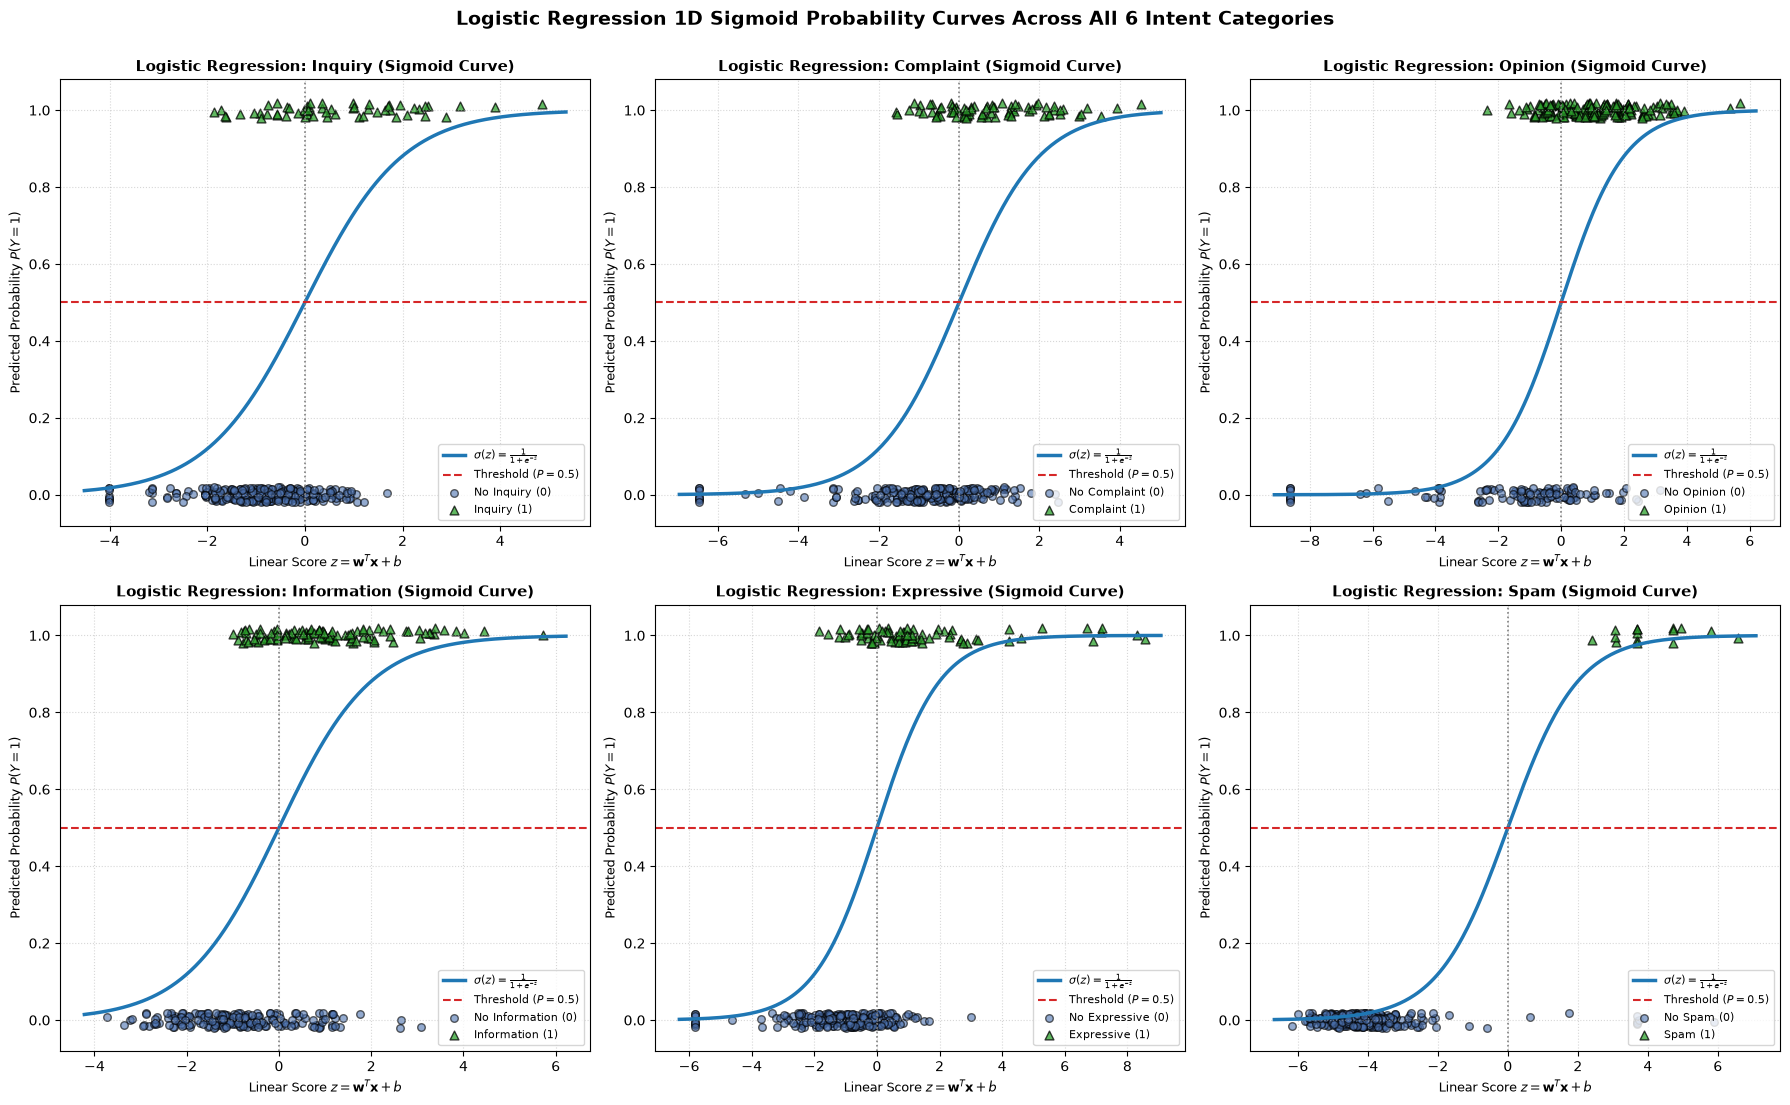

In [45]:
# 1D Sigmoid Probability Curves across all 6 Intent Categories
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

# Sample test posts for clean, uncluttered visual display
sample_size = min(300, X_test_tfidf.shape[0])
sample_idx = np.random.RandomState(42).choice(X_test_tfidf.shape[0], size=sample_size, replace=False)
X_test_sample = X_test_tfidf[sample_idx]

for i, label in enumerate(target_cols):
    # Calculate linear decision score z for each post
    z_scores = lr_model.estimators_[i].decision_function(X_test_sample)
    y_true_sample = y_test[label].iloc[sample_idx].values
    
    # Generate continuous smooth Sigmoid curve
    z_min, z_max = z_scores.min() - 0.5, z_scores.max() + 0.5
    z_line = np.linspace(z_min, z_max, 300)
    p_line = 1 / (1 + np.exp(-z_line))
    
    # Plot Sigmoid S-Curve
    axes[i].plot(z_line, p_line, color="#1f77b4", linewidth=2.5, label=r"$\sigma(z) = \frac{1}{1 + e^{-z}}$")
    
    # Plot Decision Threshold line at P = 0.5 and vertical line at z = 0
    axes[i].axhline(0.5, color="#d62728", linestyle="--", linewidth=1.5, label="Threshold ($P=0.5$)")
    axes[i].axvline(0.0, color="#7f7f7f", linestyle=":", linewidth=1.2)
    
    # Scatter sample test posts (y=0 at bottom, y=1 at top with slight vertical jitter)
    jitter = np.random.RandomState(42).uniform(-0.02, 0.02, size=len(z_scores))
    neg_mask = (y_true_sample == 0)
    pos_mask = (y_true_sample == 1)
    
    axes[i].scatter(z_scores[neg_mask], np.zeros(np.sum(neg_mask)) + jitter[neg_mask], 
                    color="#4C72B0", alpha=0.6, edgecolors='k', s=30, label=f"No {label} (0)")
    axes[i].scatter(z_scores[pos_mask], np.ones(np.sum(pos_mask)) + jitter[pos_mask], 
                    color="#2ca02c", alpha=0.75, edgecolors='k', s=40, marker='^', label=f"{label} (1)")
    
    axes[i].set_title(f"Logistic Regression: {label} (Sigmoid Curve)", fontsize=11, fontweight='bold')
    axes[i].set_xlabel(r"Linear Score $z = \mathbf{w}^T \mathbf{x} + b$", fontsize=9)
    axes[i].set_ylabel(r"Predicted Probability $P(Y=1)$", fontsize=9)
    axes[i].set_ylim(-0.08, 1.08)
    axes[i].legend(loc="lower right", fontsize=8)
    axes[i].grid(True, linestyle=":", alpha=0.5)

plt.suptitle("Logistic Regression 1D Sigmoid Probability Curves Across All 6 Intent Categories", fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Step 22: Logistic Regression Decision Boundary Equations & Model Evaluation
Calculates the linear decision boundary equations and evaluates test set predictions using Confusion Matrices and the custom Classification Report.

### 22.1 Logistic Regression Linear Decision Boundary Equations
Calculates the linear decision score for each intent category:

$$z = \text{intercept} + (w_1 \times \text{word}_1) + (w_2 \times \text{word}_2) + \dots$$

If $z > 0$ ($P > 0.5$), the model predicts that the intent is **Present (1)**.

In [46]:
from sklearn.metrics import confusion_matrix

# Custom Multi-Label Classification Report Generator (Accuracy, Precision, Recall, F1-Score)
def calculate_classification_metrics(y_true, y_pred, target_names):
    report_rows = []
    acc_list, prec_list, rec_list, f1_list = [], [], [], []
    
    for i, col in enumerate(target_names):
        y_t = y_true[col].values if isinstance(y_true, pd.DataFrame) else y_true[:, i]
        y_p = y_pred[:, i] if isinstance(y_pred, np.ndarray) else y_pred[col].values
        
        tp = int(np.sum((y_t == 1) & (y_p == 1)))
        tn = int(np.sum((y_t == 0) & (y_p == 0)))
        fp = int(np.sum((y_t == 0) & (y_p == 1)))
        fn = int(np.sum((y_t == 1) & (y_p == 0)))
        
        acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
        
        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)
        
        report_rows.append({
            'Intent Category': col,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })
        
    # Append Macro Average Row
    report_rows.append({
        'Intent Category': 'MACRO AVERAGE',
        'Accuracy': float(np.mean(acc_list)),
        'Precision': float(np.mean(prec_list)),
        'Recall': float(np.mean(rec_list)),
        'F1-Score': float(np.mean(f1_list))
    })
    
    report_df = pd.DataFrame(report_rows)
    return report_df, acc_list, prec_list, rec_list, f1_list

printmd("#### Logistic Regression Linear Decision Boundary Equations:")
for i, label in enumerate(target_cols):
    coefs = lr_model.estimators_[i].coef_[0]
    intercept = lr_model.estimators_[i].intercept_[0]
    top_3_idx = np.argsort(coefs)[-3:][::-1]
    terms = " + ".join([f"({coefs[idx]:.2f} * {feature_names[idx]})" for idx in top_3_idx])
    print(f"[{label:<11}] z = {intercept:.2f} + {terms} + ...")

#### Logistic Regression Linear Decision Boundary Equations:

[Inquiry    ] z = -0.57 + (11.95 * how) + (10.25 * why) + (9.12 * what) + ...
[Complaint  ] z = -1.45 + (6.85 * bodoh) + (6.47 * stupid) + (5.94 * shit) + ...
[Opinion    ] z = -0.98 + (7.91 * think) + (5.87 * bad) + (5.84 * like) + ...
[Information] z = -1.26 + (6.50 * datetoken) + (5.54 * pricetoken) + (5.31 * timetoken) + ...
[Expressive ] z = -0.08 + (21.21 * laugh) + (7.07 * hahahaha) + (6.40 * owai) + ...
[Spam       ] z = -3.70 + (8.69 * help) + (8.49 * cash) + (8.25 * join) + ...


### 22.2 Confusion Matrices for Logistic Regression
Evaluates True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN) per communicative intent category.

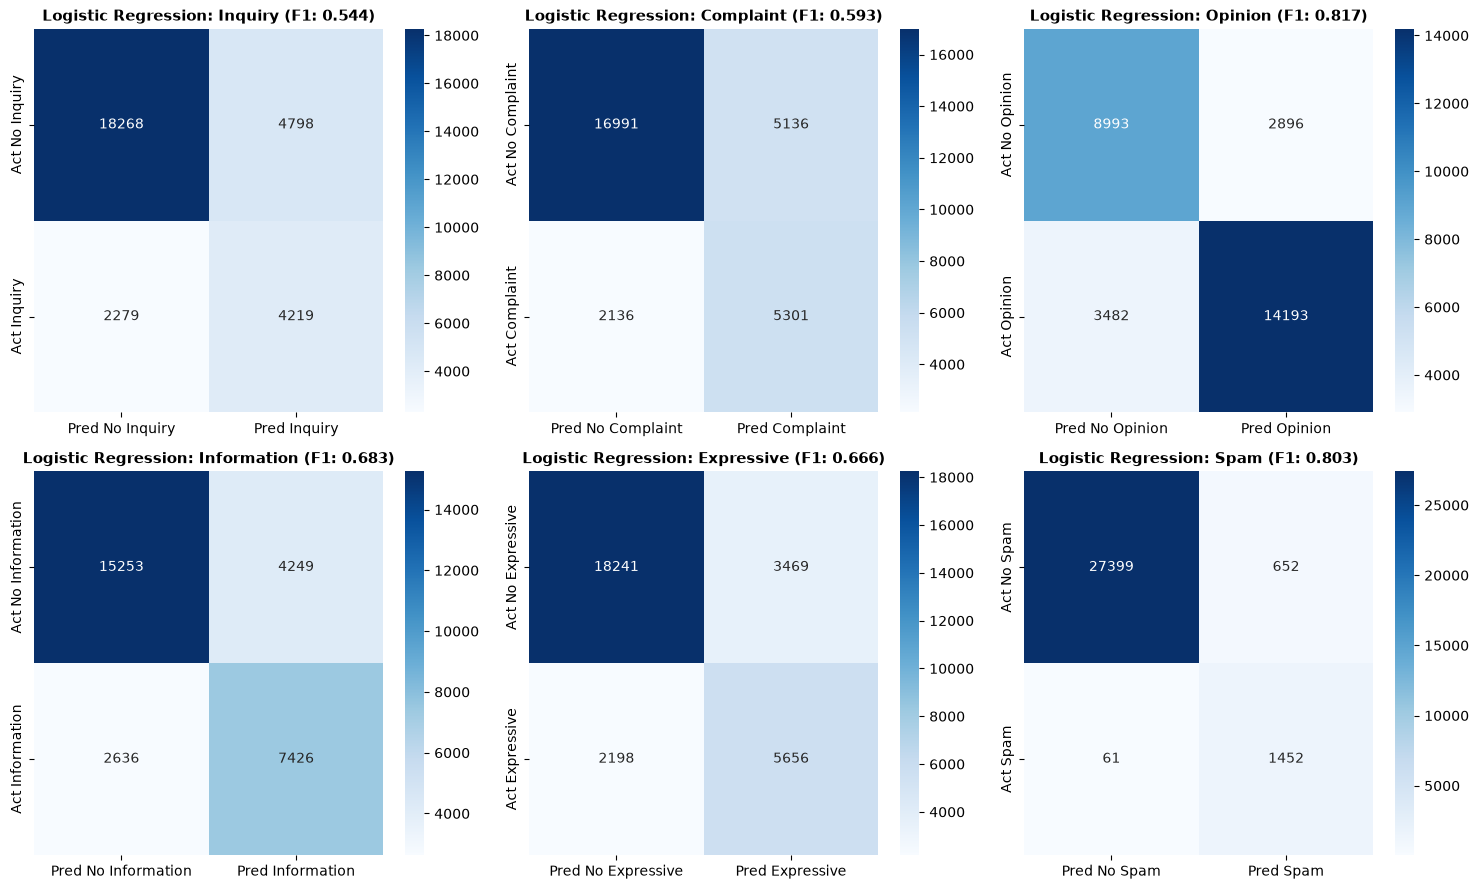

In [47]:
y_pred_lr = lr_model.predict(X_test_tfidf)

# Calculate Custom Classification Report & Metric Lists
lr_report_df, lr_accuracies, lr_precisions, lr_recalls, lr_f1_scores = calculate_classification_metrics(
    y_test, y_pred_lr, target_cols
)

# Plot Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for i, label in enumerate(target_cols):
    cm = confusion_matrix(y_test[label], y_pred_lr[:, i])
    sns.heatmap(cm, ax=axes[i], annot=True, fmt="d", cmap="Blues",
                xticklabels=[f"Pred No {label}", f"Pred {label}"],
                yticklabels=[f"Act No {label}", f"Act {label}"])
    axes[i].set_title(f"Logistic Regression: {label} (F1: {lr_f1_scores[i]:.3f})", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 22.3 Custom Classification Report for Logistic Regression
Displays the exact calculated **Accuracy**, **Precision**, **Recall**, and **F1-Score** alongside the **Macro Average**.

In [48]:
printmd("#### Classification Report for Logistic Regression:")
display(lr_report_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}'
}))

#### Classification Report for Logistic Regression:

,Intent Category,Accuracy,Precision,Recall,F1-Score
0,Inquiry,0.7606,0.4679,0.6493,0.5439
1,Complaint,0.7540,0.5079,0.7128,0.5932
2,Opinion,0.7843,0.8305,0.8030,0.8165
3,Information,0.7671,0.6361,0.7380,0.6833
4,Expressive,0.8083,0.6198,0.7201,0.6662
5,Spam,0.9759,0.6901,0.9597,0.8029
6,MACRO AVERAGE,0.8084,0.6254,0.7638,0.6843


# Step 23: Train One-vs-Rest Linear Support Vector Classifier (LinearSVC) Model
Train One-vs-Rest Linear Support Vector Classifier (`LinearSVC`) with balanced class weights to maximize the geometric margin across all 6 communicative intent categories.

In [49]:
from sklearn.svm import LinearSVC

svc_model = OneVsRestClassifier(LinearSVC(class_weight='balanced', max_iter=2000, random_state=42))
svc_model.fit(X_train_tfidf, y_train)

# Persist Linear SVC model artifact
joblib_dump(svc_model, "linear_svc_model.joblib")
printmd("**Linear SVC Model:** Successfully trained and saved to `linear_svc_model.joblib`.")

**Linear SVC Model:** Successfully trained and saved to `linear_svc_model.joblib`.

# Step 24: Linear SVC Feature Interpretation, Support Vector Calculation & Margin Ramp Response

### 1. Linear SVC Decision Function Formulation:
Linear SVC computes the scalar decision score $z$ (signed distance to the separating hyperplane) for each comment vector $\mathbf{x}$:

$$z = \mathbf{w}^T \mathbf{x} + b = \sum_{j=1}^n w_j x_j + b$$

### 2. Functional Margin & Support Vector Identification:
For binary classification with labels mapped to $y_i \in \{-1, +1\}$, the **Functional Margin** is defined as $y_i (\mathbf{w}^T \mathbf{x}_i + b)$.
A comment $\mathbf{x}_i$ is identified as a **Support Vector** (or margin violator) if and only if it satisfies the margin condition:

$$y_i (\mathbf{w}^T \mathbf{x}_i + b) \le 1 \quad \iff \quad \text{Slack Variable } \xi_i = \max(0, 1 - y_i z_i) \ge 0$$

- **$y_i z_i > 1$**: Correctly classified outside the margin buffer (high confidence, non-support vector).
- **$0 \le y_i z_i \le 1$**: Sits directly on or inside the **Margin Buffer $[-1, +1]$** (Support Vector holding up the boundary).
- **$y_i z_i < 0$**: Margin violation / misclassified post ($z_i$ has the wrong sign).

### 3. Linear SVC Clamped Margin Ramp Response:
Linear SVC saturates to class $-1.0$ when $z \le -1$ and class $+1.0$ when $z \ge +1$, ramping linearly across the **Margin Buffer $[-1, +1]$**:

$$f_{\text{SVC}}(z) = \text{clip}(z, -1, 1) = \begin{cases} -1.0 & \text{if } z < -1 \\ z & \text{if } -1 \le z \le 1 \\ +1.0 & \text{if } z > 1 \end{cases}$$

### 24.1 Top Predictive Linear Weights per Intent Category
Words with the highest positive coefficient weights ($w_j$) that strongly push predictions above the decision threshold.

In [50]:
top_words_svc = {}
for i, label in enumerate(target_cols):
    coefs = svc_model.estimators_[i].coef_[0]
    top_indices = np.argsort(coefs)[-8:][::-1]
    top_words_svc[label] = [f"{feature_names[idx]} ({coefs[idx]:.2f})" for idx in top_indices]
    
printmd("#### Linear SVC Top 8 Predictive Features per Intent Class:")
display(pd.DataFrame(top_words_svc))

#### Linear SVC Top 8 Predictive Features per Intent Class:

,Inquiry,Complaint,Opinion,Information,Expressive,Spam
0,how (5.38),annoy (3.23),think (3.76),datetoken (2.43),laugh (10.38),message newbie (2.25)
1,why (4.25),stupid (3.17),probably (3.08),injured (2.41),hahahaha (5.70),luck urltoken (2.19)
2,what (3.56),ridiculous (2.97),guess (2.86),selatan (2.29),cukur (4.10),urltoken new (2.06)
3,where (3.49),sigh (2.90),useless (2.84),starter urltoken (2.24),lel (3.65),urltoken mari (2.04)
4,which (3.46),fucker (2.90),bad (2.84),pricetoken (2.22),kekk (3.49),live la (2.03)
5,want ask (3.45),haiz (2.89),bullshit (2.82),shit urltoken (2.18),kekwa (3.39),urltoken bonus (2.02)
6,curious (3.43),overprice (2.88),maybe (2.81),google (2.18),owai (3.38),need thank (2.02)
7,anybody (2.85),suck (2.84),ugly (2.76),iinm (2.18),hahahahaha (3.35),urltoken (2.01)


### 24.2 Support Vectors Calculation & Margin Statistics
We calculate the exact functional margin $y_i z_i$ for all test comments and quantify the total number of **Support Vectors** (posts lying within or violating the margin buffer $y_i z_i \le 1$) across all 6 intent categories.

In [51]:
# Support Vectors Calculation across all 6 Intent Categories
sv_summary = []
total_test_samples = X_test_tfidf.shape[0]

for i, label in enumerate(target_cols):
    z_scores = svc_model.estimators_[i].decision_function(X_test_tfidf)
    y_binary = y_test[label].values if isinstance(y_test, pd.DataFrame) else y_test[:, i]
    
    # Convert binary {0, 1} to {-1, +1} for functional margin evaluation
    y_pm = np.where(y_binary == 1, 1.0, -1.0)
    functional_margins = y_pm * z_scores
    
    # Support Vectors: functional margin <= 1.0 (on margin boundary, inside buffer, or misclassified)
    sv_mask = functional_margins <= 1.0
    sv_count = int(np.sum(sv_mask))
    
    # Breakdown: Inside Margin vs Misclassified (Violations)
    on_or_inside_margin = int(np.sum((functional_margins >= 0) & (functional_margins <= 1.0)))
    misclassified = int(np.sum(functional_margins < 0))
    
    sv_summary.append({
        'Intent Category': label,
        'Total Test Posts': total_test_samples,
        'Total Support Vectors': sv_count,
        'Support Vector Ratio (%)': f"{sv_count / total_test_samples * 100:.2f}%",
        'Inside Margin Buffer [0, 1]': on_or_inside_margin,
        'Margin Violations (z < 0)': misclassified
    })

sv_df = pd.DataFrame(sv_summary)
printmd("#### Support Vectors Quantification per Intent Category (Formula: $y_i z_i \le 1$):")
display(sv_df)

#### Support Vectors Quantification per Intent Category (Formula: $y_i z_i \le 1$):

,Intent Category,Total Test Posts,Total Support Vectors,Support Vector Ratio (%),"Inside Margin Buffer [0, 1]",Margin Violations (z < 0)
0,Inquiry,29564,24094,81.50%,16950,7144
1,Complaint,29564,22897,77.45%,15767,7130
2,Opinion,29564,21024,71.11%,14238,6786
3,Information,29564,22825,77.21%,15624,7201
4,Expressive,29564,21119,71.43%,15131,5988
5,Spam,29564,3969,13.43%,3311,658


### 24.3 Linear SVC Margin Ramp & Support Vector Buffer Response Plot
Visualizes the **Linear SVC Margin Ramp Function** $f(z) = \text{clip}(z, -1, 1)$ across the scalar decision score $z = \mathbf{w}^T \mathbf{x} + b$:
- **Green Line**: Linear SVC Clamped Margin Response ($f(z) = \text{clip}(z, -1, 1)$)
- **Grey Shaded Region**: SVC Margin Buffer Zone $[-1, +1]$ (where Support Vectors lie)
- **Decision Boundaries**: Negative Boundary at $z = -1$, Separating Hyperplane at $z = 0$, Positive Boundary at $z = +1$

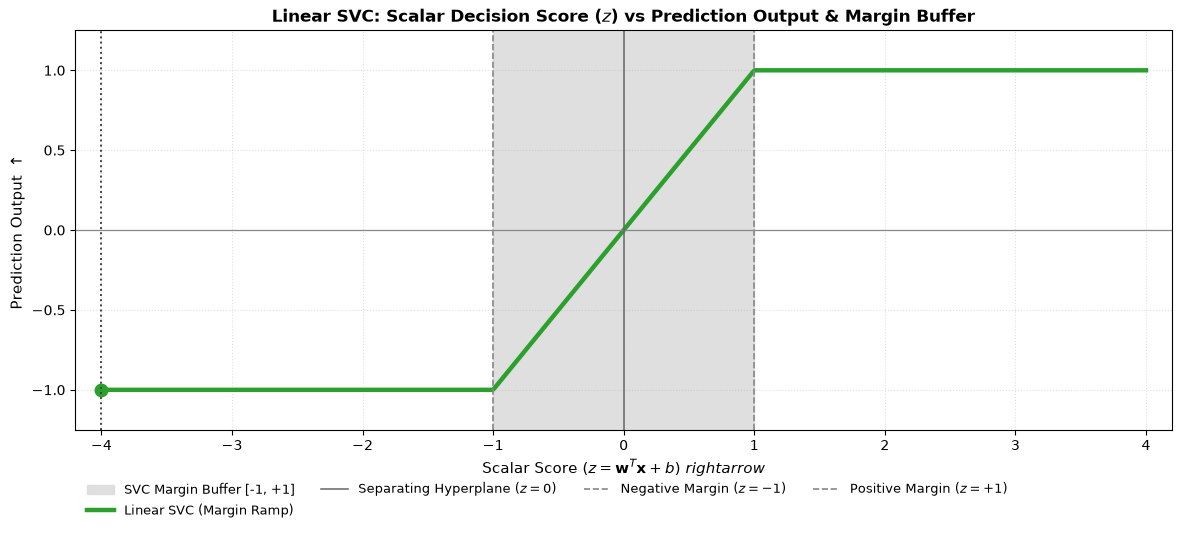

In [52]:
# Plot Linear SVC Margin Ramp Function & Margin Buffer Zone
z_range = np.linspace(-4, 4, 500)
svc_ramp = np.clip(z_range, -1.0, 1.0)

plt.figure(figsize=(12, 5.5))

# 1. Highlight SVC Margin Buffer [-1, +1]
plt.axvspan(-1, 1, color='#dcdcdc', alpha=0.9, label='SVC Margin Buffer [-1, +1]')

# 2. Plot Linear SVC Clamped Margin Ramp Curve (Green)
plt.plot(z_range, svc_ramp, color='#2ca02c', linewidth=3.2, label='Linear SVC (Margin Ramp)')

# 3. Reference Coordinate Axes
plt.axhline(0, color='#888888', linestyle='-', linewidth=0.9)
plt.axvline(0, color='#666666', linestyle='-', linewidth=1.1, label='Separating Hyperplane ($z=0$)')
plt.axvline(-1, color='#888888', linestyle='--', linewidth=1.2, label='Negative Margin ($z=-1$)')
plt.axvline(1, color='#888888', linestyle='--', linewidth=1.2, label='Positive Margin ($z=+1$)')

# 4. Highlight Saturated Anchor Point at z = -4
plt.plot(-4, -1.0, 'o', color='#2ca02c', markersize=9)
plt.axvline(-4, color='#444444', linestyle=':', linewidth=1.4)

plt.title("Linear SVC: Scalar Decision Score ($z$) vs Prediction Output & Margin Buffer", fontsize=12, fontweight='bold')
plt.xlabel(r"Scalar Score ($z = \mathbf{w}^T \mathbf{x} + b$) $rightarrow$", fontsize=11)
plt.ylabel(r"Prediction Output $\uparrow$", fontsize=11)
plt.xlim(-4.2, 4.2)
plt.ylim(-1.25, 1.25)
plt.yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
plt.xticks([-4, -3, -2, -1, 0, 1, 2, 3, 4])
plt.legend(loc='lower left', bbox_to_anchor=(0.0, -0.25), ncol=4, frameon=False, fontsize=9.5)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

### 24.4 Linear SVC Margin Ramp Response Across All 6 Intent Categories
Plots each label's SVC decision scores against the margin ramp function, showing how test posts sit relative to the ±1 margin buffer.

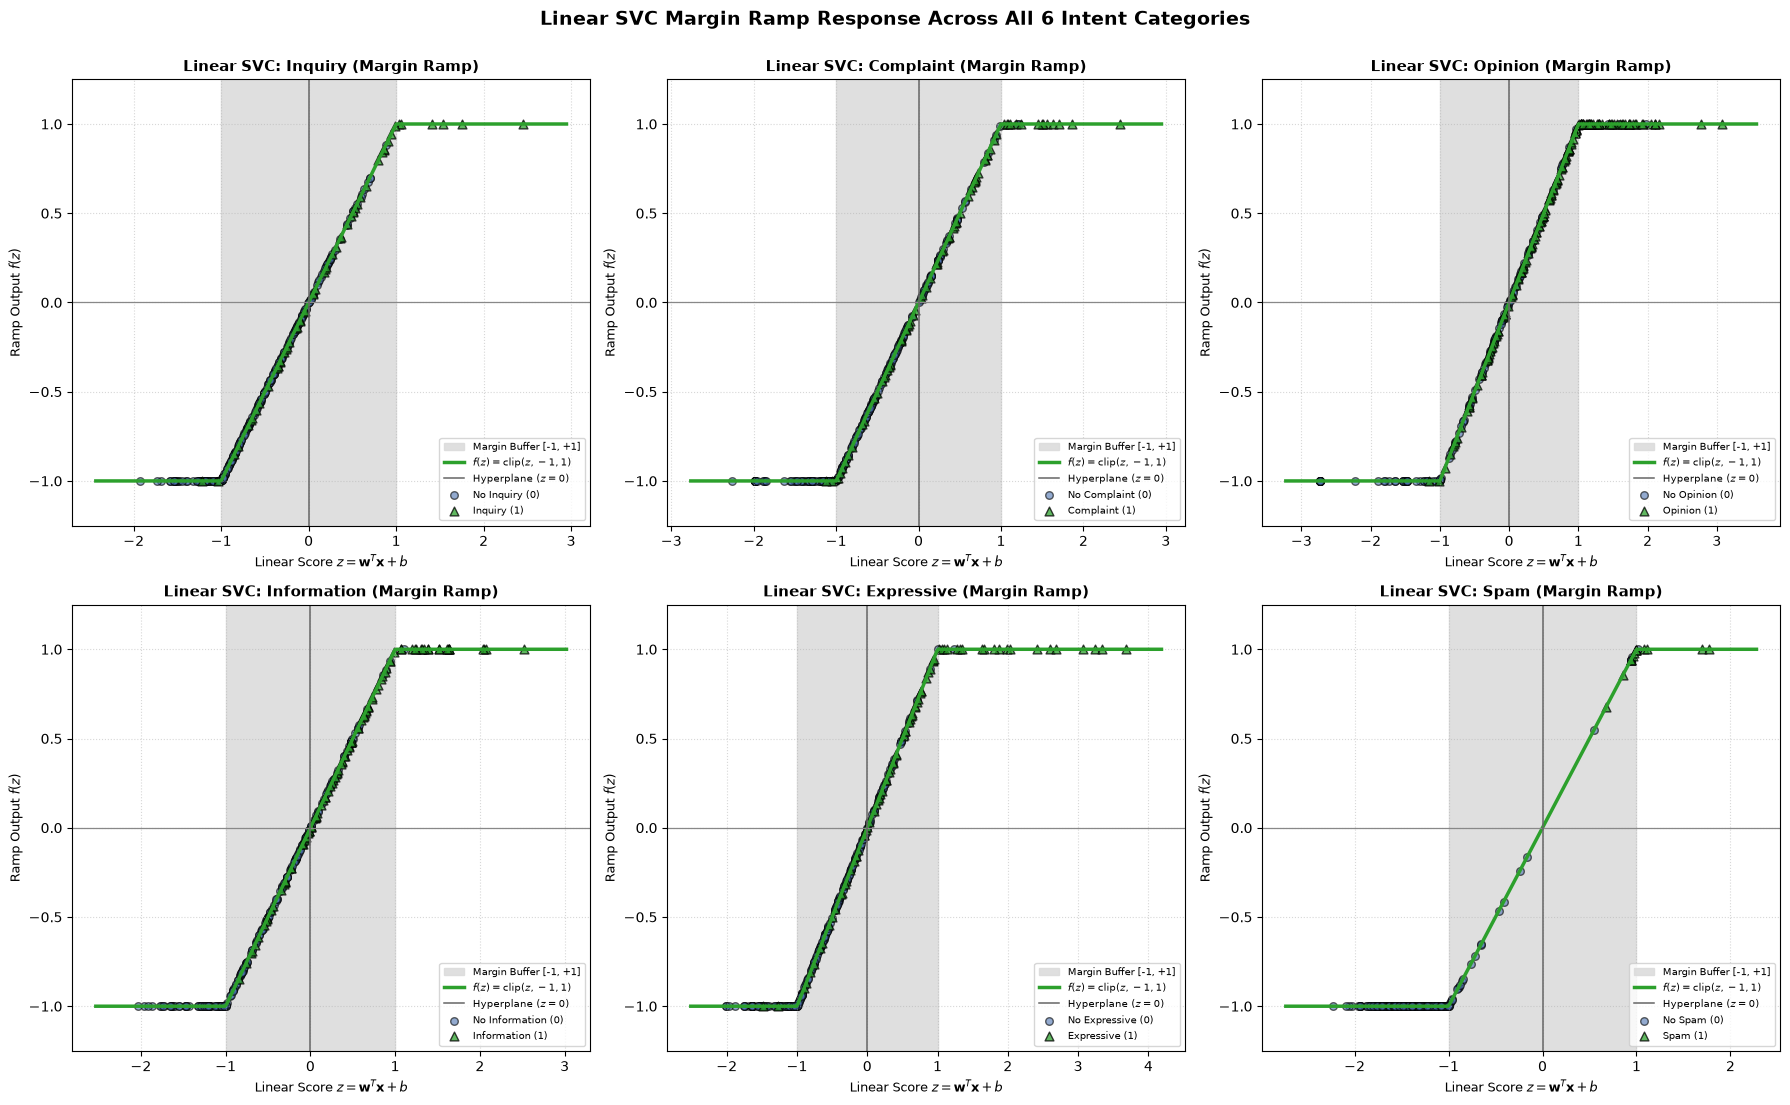

In [53]:
# Linear SVC Margin Ramp Function per Intent Category (All 6 Labels)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

sample_size = min(300, X_test_tfidf.shape[0])
sample_idx = np.random.RandomState(42).choice(X_test_tfidf.shape[0], size=sample_size, replace=False)
X_test_sample = X_test_tfidf[sample_idx]

for i, label in enumerate(target_cols):
    z_scores = svc_model.estimators_[i].decision_function(X_test_sample)
    y_true_sample = y_test[label].iloc[sample_idx].values

    z_min, z_max = min(z_scores.min() - 0.5, -1.5), max(z_scores.max() + 0.5, 1.5)
    z_line = np.linspace(z_min, z_max, 300)
    f_line = np.clip(z_line, -1.0, 1.0)

    axes[i].axvspan(-1, 1, color='#dcdcdc', alpha=0.9, label='Margin Buffer [-1, +1]')
    axes[i].plot(z_line, f_line, color="#2ca02c", linewidth=2.5, label=r"$f(z) = \mathrm{clip}(z, -1, 1)$")
    axes[i].axhline(0.0, color="#888888", linestyle="-", linewidth=0.9)
    axes[i].axvline(0.0, color="#666666", linestyle="-", linewidth=1.1, label="Hyperplane ($z=0$)")

    neg_mask = (y_true_sample == 0)
    pos_mask = (y_true_sample == 1)
    f_scores = np.clip(z_scores, -1.0, 1.0)

    axes[i].scatter(z_scores[neg_mask], f_scores[neg_mask],
                    color="#4C72B0", alpha=0.6, edgecolors='k', s=30, label=f"No {label} (0)")
    axes[i].scatter(z_scores[pos_mask], f_scores[pos_mask],
                    color="#2ca02c", alpha=0.75, edgecolors='k', s=40, marker='^', label=f"{label} (1)")

    axes[i].set_title(f"Linear SVC: {label} (Margin Ramp)", fontsize=11, fontweight='bold')
    axes[i].set_xlabel(r"Linear Score $z = \mathbf{w}^T \mathbf{x} + b$", fontsize=9)
    axes[i].set_ylabel(r"Ramp Output $f(z)$", fontsize=9)
    axes[i].set_ylim(-1.25, 1.25)
    axes[i].legend(loc="lower right", fontsize=7.5)
    axes[i].grid(True, linestyle=":", alpha=0.5)

plt.suptitle("Linear SVC Margin Ramp Response Across All 6 Intent Categories", fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Step 25: Linear SVC Model Evaluation & Custom Classification Report
We evaluate the Linear SVC model using Confusion Matrix heatmaps and generate the custom Classification Report table.

### 25.1 Confusion Matrices for Linear SVC
Evaluates True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN) per communicative intent category.

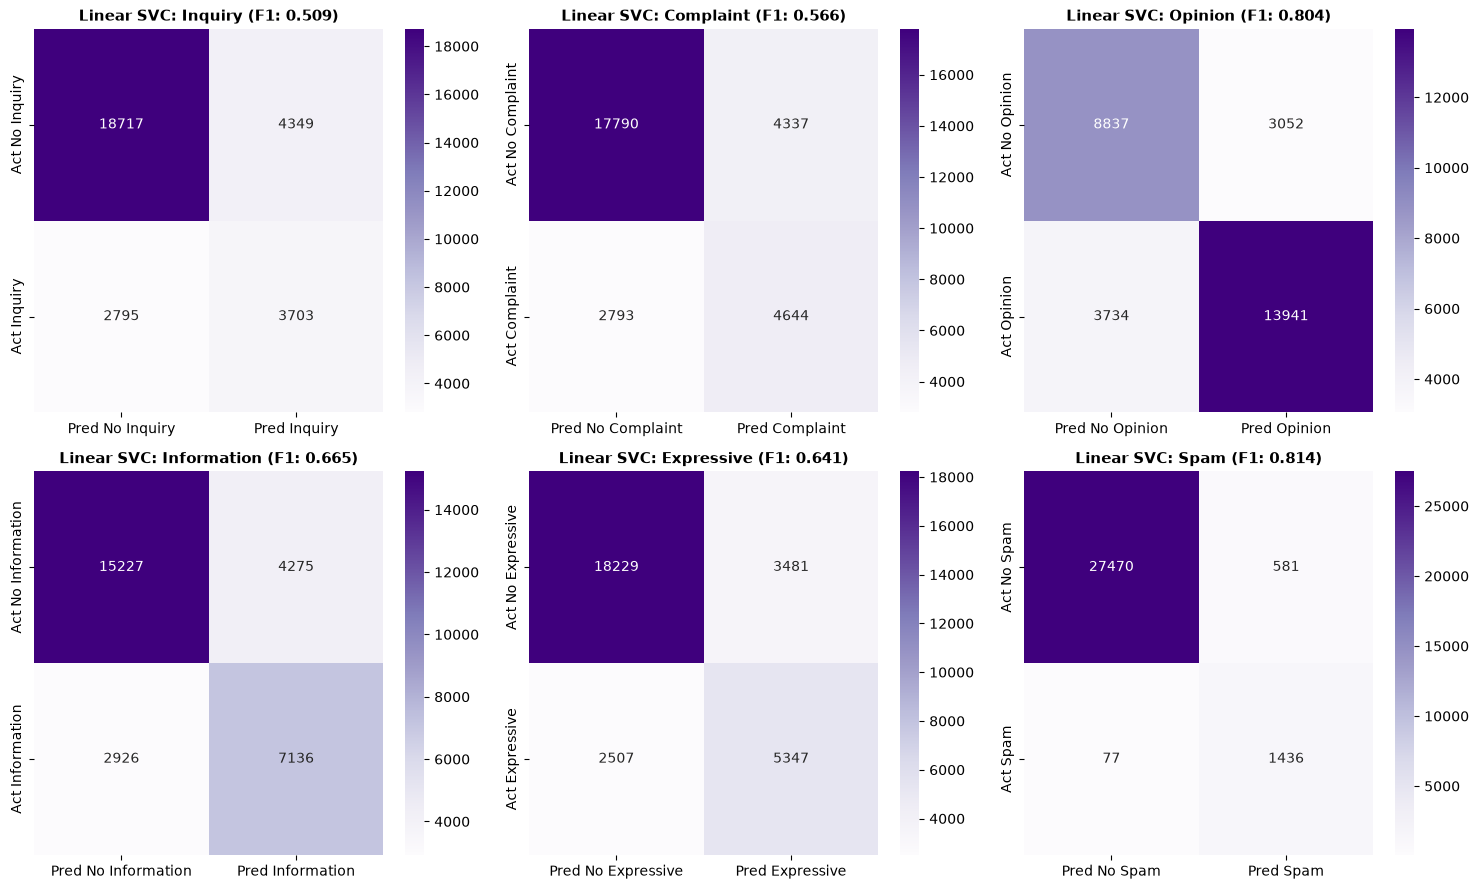

In [54]:
y_pred_svc = svc_model.predict(X_test_tfidf)

# Calculate Custom Classification Report & Metric Lists for Linear SVC
svc_report_df, svc_accuracies, svc_precisions, svc_recalls, svc_f1_scores = calculate_classification_metrics(
    y_test, y_pred_svc, target_cols
)

# Plot Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for i, label in enumerate(target_cols):
    cm = confusion_matrix(y_test[label], y_pred_svc[:, i])
    sns.heatmap(cm, ax=axes[i], annot=True, fmt="d", cmap="Purples",
                xticklabels=[f"Pred No {label}", f"Pred {label}"],
                yticklabels=[f"Act No {label}", f"Act {label}"])
    axes[i].set_title(f"Linear SVC: {label} (F1: {svc_f1_scores[i]:.3f})", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 25.2 Custom Classification Report for Linear SVC
Displays the exact calculated **Accuracy**, **Precision**, **Recall**, and **F1-Score** alongside the **Macro Average**.

In [55]:
printmd("#### Classification Report for Linear SVC:")
display(svc_report_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}'
}))

#### Classification Report for Linear SVC:

,Intent Category,Accuracy,Precision,Recall,F1-Score
0,Inquiry,0.7584,0.4599,0.5699,0.5090
1,Complaint,0.7588,0.5171,0.6244,0.5657
2,Opinion,0.7705,0.8204,0.7887,0.8043
3,Information,0.7564,0.6254,0.7092,0.6646
4,Expressive,0.7975,0.6057,0.6808,0.6411
5,Spam,0.9777,0.7119,0.9491,0.8136
6,MACRO AVERAGE,0.8032,0.6234,0.7204,0.6664


# Step 26: Comprehensive All-Metrics Model Comparison
Consolidated comparison of **Accuracy**, **Precision**, **Recall**, and **F1-Score** between Logistic Regression and Linear SVC across all 6 intent categories + Macro Average.

### Overall Model Performance Comparison (Logistic Regression vs Linear SVC)

,Category,LR Accuracy,SVC Accuracy,LR Precision,SVC Precision,LR Recall,SVC Recall,LR F1-Score,SVC F1-Score
0,Inquiry,0.761,0.758,0.468,0.460,0.649,0.570,0.544,0.509
1,Complaint,0.754,0.759,0.508,0.517,0.713,0.624,0.593,0.566
2,Opinion,0.784,0.770,0.831,0.820,0.803,0.789,0.817,0.804
3,Information,0.767,0.756,0.636,0.625,0.738,0.709,0.683,0.665
4,Expressive,0.808,0.797,0.620,0.606,0.720,0.681,0.666,0.641
5,Spam,0.976,0.978,0.690,0.712,0.960,0.949,0.803,0.814
6,MACRO AVERAGE,0.808,0.803,0.625,0.623,0.764,0.720,0.684,0.666


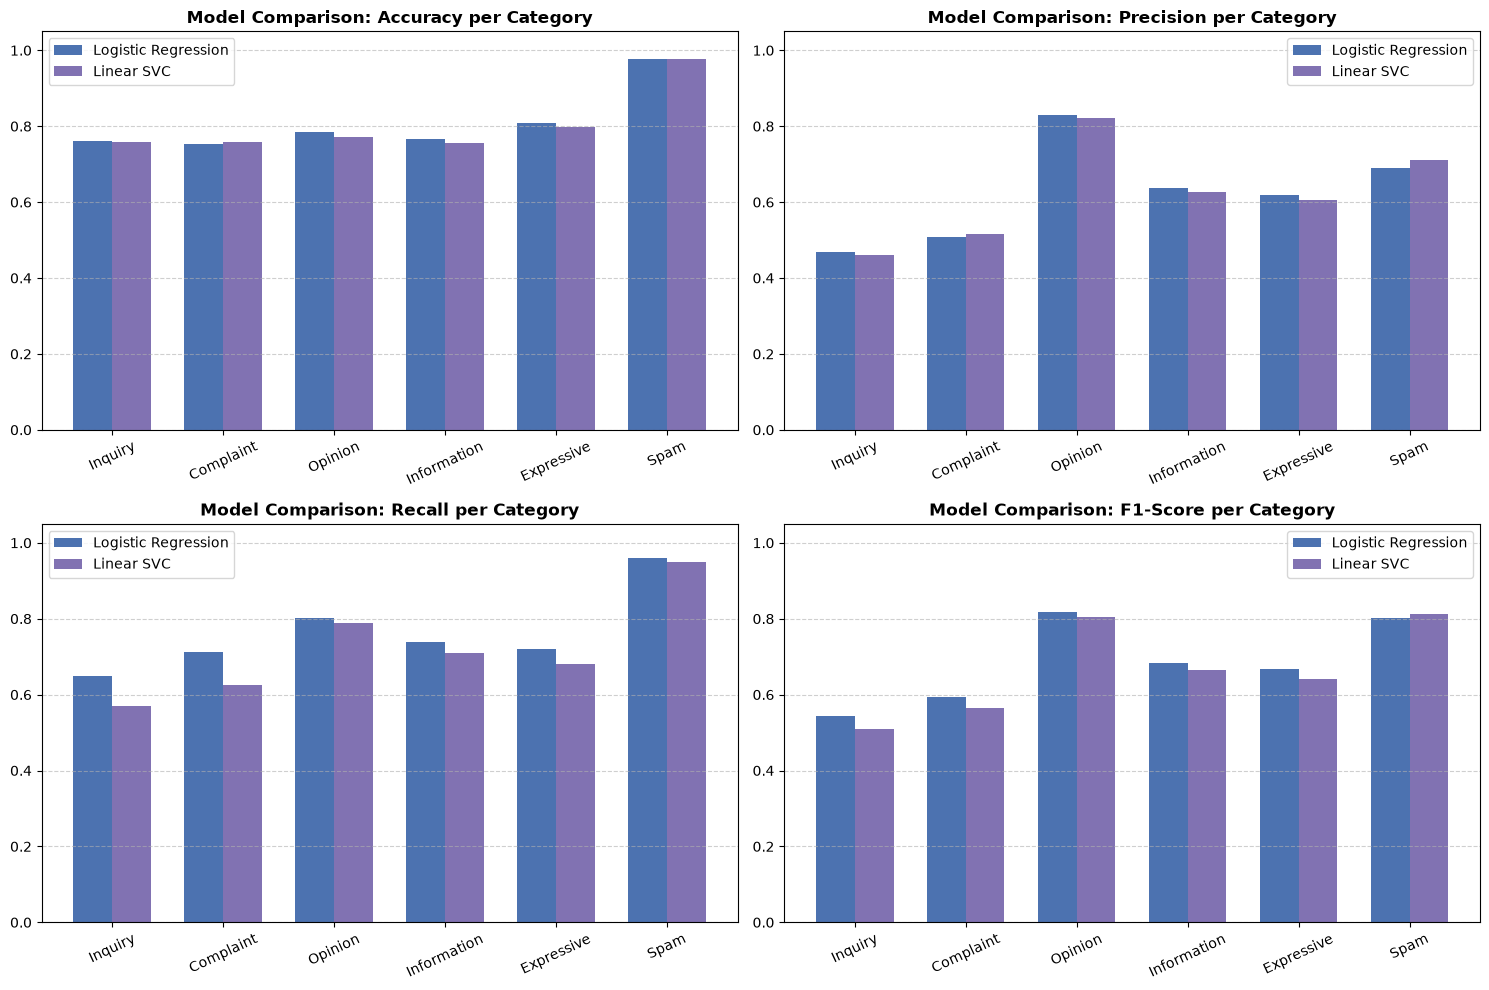

In [56]:
# Consolidated All-Metrics Comparison Table
comp_table = pd.DataFrame({
    'Category': target_cols,
    'LR Accuracy': lr_accuracies,
    'SVC Accuracy': svc_accuracies,
    'LR Precision': lr_precisions,
    'SVC Precision': svc_precisions,
    'LR Recall': lr_recalls,
    'SVC Recall': svc_recalls,
    'LR F1-Score': lr_f1_scores,
    'SVC F1-Score': svc_f1_scores,
})

# Add Macro Average Row
comp_table.loc[len(comp_table)] = {
    'Category': 'MACRO AVERAGE',
    'LR Accuracy': np.mean(lr_accuracies),
    'SVC Accuracy': np.mean(svc_accuracies),
    'LR Precision': np.mean(lr_precisions),
    'SVC Precision': np.mean(svc_precisions),
    'LR Recall': np.mean(lr_recalls),
    'SVC Recall': np.mean(svc_recalls),
    'LR F1-Score': np.mean(lr_f1_scores),
    'SVC F1-Score': np.mean(svc_f1_scores),
}

printmd("### Overall Model Performance Comparison (Logistic Regression vs Linear SVC)")
display(comp_table.style.format({col: "{:.3f}" for col in comp_table.columns if col != 'Category'}))

# Side-by-Side Multi-Metric Visual Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics_to_plot = [
    ("Accuracy", "LR Accuracy", "SVC Accuracy"),
    ("Precision", "LR Precision", "SVC Precision"),
    ("Recall", "LR Recall", "SVC Recall"),
    ("F1-Score", "LR F1-Score", "SVC F1-Score")
]

x = np.arange(len(target_cols))
width = 0.35

for idx, (m_name, lr_c, svc_c) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    ax.bar(x - width/2, comp_table.iloc[:6][lr_c], width, label="Logistic Regression", color="#4C72B0")
    ax.bar(x + width/2, comp_table.iloc[:6][svc_c], width, label="Linear SVC", color="#8172B2")
    ax.set_title(f"Model Comparison: {m_name} per Category", fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(target_cols, rotation=25)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Step 27: Preprocessing Pipeline Encapsulation & Model Artifact Loading
We encapsulate Steps 2 through 16 into a clean standalone `preprocess_pipeline(raw_text)` function and load the saved `.joblib` model artifacts from disk for deployment.

In [57]:
from joblib import load as joblib_load

# Encapsulate Steps 2 to 16 in exact execution sequence
def preprocess_pipeline(raw_text):
    # Step 2: Remove Lowyat Quotes, BBCode, Signatures, and HTML
    text = remove_quote_blocks(raw_text)
    text = remove_spoilers(text)
    text = remove_images_and_code(text)
    text = remove_media_bbcode(text)
    text = remove_formatting_tags(text)
    text = remove_signatures_and_redactions(text)
    text = remove_html_tags(text)
    
    # Step 3: Special Element Masking (Time first, then Date)
    text = mask_emails(text)
    text = mask_urls(text)
    text = mask_phone_numbers(text)
    text = mask_nric(text)
    text = mask_prices(text)
    text = mask_time(text)
    text = mask_dates(text)
    
    # Step 4: Remove Elongated Characters & Repeating Emojis
    text = remove_elongated_content(text)
    
    # Step 5: Convert Emojis to Text
    text = convert_emojis(text)
    
    # Step 6: Lowercasing
    text = to_lowercase(text)
    
    # Step 7: Slang Normalization (Hybrid)
    text = normalize_slangs(text)
    
    # Step 8: Fix Contractions
    text = fix_contractions(text)
    
    # Step 9: Remove All Punctuations
    text = remove_punctuations(text)
    
    # Step 10: Split Alphanumeric Tokens & Remove Numbers
    text = split_and_remove_numbers(text)
    
    # Step 11: Remove Non-Latin Characters
    text = remove_non_latin(text)
    
    # Step 12: Word Tokenization
    tokens = tokenize_words(text)
    
    # Step 13: Language Classification and Token Tagging
    tagged = tag_tokens(tokens)
    
    # Step 14: Part-of-Speech (POS) Tagging for English Tokens (on full sequences)
    pos_tagged = pos_tag_english_tokens(tagged)
    
    # Step 15: Morphological Normalization (Lemmatization with POS & Stemming)
    morph_tokens = lemmatize_and_stem(pos_tagged)
    
    # Step 16: Stop Word Removal (Applied on Lemmatized/Stemmed Tokens)
    filtered = remove_stopwords(morph_tokens)
    
    return ' '.join([t[0] for t in filtered])

# Load serialized artifacts from disk
loaded_tfidf = joblib_load("tfidf_vectorizer.joblib")
loaded_lr = joblib_load("logistic_regression_model.joblib")
loaded_svc = joblib_load("linear_svc_model.joblib")
printmd("**Artifacts Status:** All serialized models (`TF-IDF`, `Logistic Regression`, `Linear SVC`) loaded successfully from disk.")

**Artifacts Status:** All serialized models (`TF-IDF`, `Logistic Regression`, `Linear SVC`) loaded successfully from disk.

# Step 28: Real-Time Prediction on Unseen Posts (Showing Both Models)
Execute real-time multi-label classification on brand-new unseen forum posts, displaying predictions simultaneously from **both Logistic Regression and Linear SVC**.

In [ ]:
def predict_unseen(raw_text):
    cleaned_input = preprocess_pipeline(raw_text)
    
    if not cleaned_input.strip():
        return {
            "raw_text": raw_text,
            "cleaned_text": cleaned_input,
            "lr_intents": ["Neutral/None"],
            "svc_intents": ["Neutral/None"]
        }
    
    vectorized_input = loaded_tfidf.transform([cleaned_input])
    
    # 1. Logistic Regression Prediction
    lr_pred_array = loaded_lr.predict(vectorized_input)[0]
    lr_intents = [target_cols[i] for i, val in enumerate(lr_pred_array) if val == 1]
    
    # 2. Linear SVC Prediction
    svc_pred_array = loaded_svc.predict(vectorized_input)[0]
    svc_intents = [target_cols[i] for i, val in enumerate(svc_pred_array) if val == 1]
    
    return {
        "raw_text": raw_text,
        "cleaned_text": cleaned_input,
        "lr_intents": lr_intents if lr_intents else ["Neutral/None"],
        "svc_intents": svc_intents if svc_intents else ["Neutral/None"]
    }

# 1. Automated Test Verification on Sample Forum Comments
test_samples = [
    "QUOTE(seller @ 10am) barang rosak teruk refund RM50 https://shop.com/scam please help!!!",
    "bila tarikh release movie baru tu? nak book ticket kat shopee",
    "i",
    "may i know which course you chosing"
]

printmd("#### Automated Verification on Test Sample Posts:")
for post in test_samples:
    result = predict_unseen(post)
    print(f"Post        : {result['raw_text']}")
    print(f"Cleaned     : {result['cleaned_text']}")
    print(f"Logistic Reg: {result['lr_intents']}")
    print(f"Linear SVC  : {result['svc_intents']}\n")

# 2. Interactive Input While-Loop (Exits only on 'q')
def interactive_intent_predictor():
    printmd("### Interactive Forum Comment Intent Predictor")
    printmd("Type any forum comment below to test intent classification across **both models** (or enter '**q**' to quit):")
    
    while True:
        user_post = input("\nYour comment (or 'q' to quit): ").strip()
        if user_post.lower() == 'q':
            printmd("**Exiting interactive session.**")
            break
        if not user_post:
            print("Please enter a non-empty comment.")
            continue
            
        res = predict_unseen(user_post)
        printmd("#### Prediction Output:")
        printmd(f"- **Raw Input:** `{res['raw_text']}`")
        printmd(f"- **Cleaned Input:** `{res['cleaned_text']}`")
        printmd(f"- **Logistic Regression Intents:** **{', '.join(res['lr_intents'])}**")
        printmd(f"- **Linear SVC Intents:** **{', '.join(res['svc_intents'])}**")

# Run interactive predictor
interactive_intent_predictor()

#### Automated Verification on Test Sample Posts:

Post        : QUOTE(seller @ 10am) barang rosak teruk refund RM50 https://shop.com/scam please help!!!
Cleaned     : barang rosak teruk refund pricetoken urltoken help
Logistic Reg: ['Inquiry', 'Complaint', 'Information', 'Spam']
Linear SVC  : ['Complaint', 'Information', 'Spam']

Post        : bila tarikh release movie baru tu? nak book ticket kat shopee
Cleaned     : tarikh release movie baru mahu book ticket shopee
Logistic Reg: ['Inquiry', 'Complaint', 'Information']
Linear SVC  : ['Inquiry', 'Information']

Post        : i
Cleaned     : 
Logistic Reg: ['Neutral/None']
Linear SVC  : ['Neutral/None']

Post        : may i know which course you chosing
Cleaned     : know which course chosing
Logistic Reg: ['Inquiry', 'Information']
Linear SVC  : ['Information']



### Interactive Forum Comment Intent Predictor

Type any forum comment below to test intent classification across **both models** (or enter '**q**' to quit):